# 4팀 초급 프로젝트

## 트랙 B. 서울 지하철 유/무임 승하차 구조 분석

# 0. 라이브러리 및 환경 설정

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (12.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

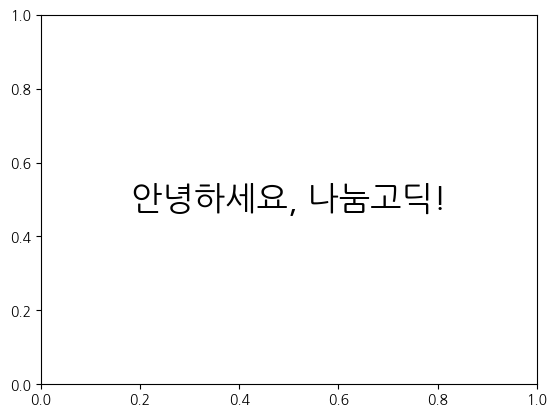

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import seaborn as sns
from matplotlib import rc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
import requests
import os
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.font_manager as fm
!apt-get install -y fonts-nanum
!fc-cache -fv
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.text(0.5, 0.5, '안녕하세요, 나눔고딕!', ha='center', va='center', size=24)
plt.show()


sns.set(style="whitegrid")

# 한글 폰트 설정
rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

#한글화 코드

# 1. 데이터 불러오기

- Google Colab 환경에서 분석 수행.
- Google Drive를 /content/drive에 마운트하여 데이터를 불러옴.
- 분석에 사용된 데이터 파일은 초급 프로젝트 폴더 내에 저장.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# csv 파일 불러오기
file_path = '/content/drive/MyDrive/초급 프로젝트/서울시 지하철 호선별 역별 유_무임 승하차 인원 정보_202505-202604.csv'
subway_df = pd.read_csv(file_path, encoding='cp949')

file_path2 = '/content/drive/MyDrive/초급 프로젝트/고령인구비율_시도_시_군_구__20260602114504.csv'
고령_df = pd.read_csv(file_path2, encoding='cp949')

file_path3 = '/content/drive/MyDrive/초급 프로젝트/수도권 자치구 맵핑용.csv'
subway_loc_df = pd.read_csv(file_path3, encoding='cp949')

# 서울 내 무임승차가 많은 top 20 역들의 위치데이터
top20_위치 = pd.read_csv('/content/drive/MyDrive/초급 프로젝트/seoul_20_stations.csv', encoding='cp949')

# 상위,하위 20개 역의 위치데이터
top_subway_file = '/content/drive/MyDrive/초급 프로젝트/top20_stations.csv'
bottom_subway_file = '/content/drive/MyDrive/초급 프로젝트/bottom20_stations.csv'

# 서울시 경로당 위치데이터
welfare_file = '/content/drive/MyDrive/초급 프로젝트/senior_facilities_geocoded.csv'

# 시간대별 노인 승하차 데이터
노인_df = pd.read_csv('/content/drive/MyDrive/초급 프로젝트/서울교통공사_역별 일별 시간대별 노인 승하차인원_20251231.csv', encoding='cp949')


print('subway_df shape:', subway_df.shape)
print('고령_df shape:', 고령_df.shape)
print('subway_loc_df shape', subway_loc_df.shape)


subway_df shape: (7456, 8)
고령_df shape: (70, 5)
subway_loc_df shape (69, 4)


# 2. 데이터 전처리

## 2-1. 데이터 정제

### 2-1-1. 결측치 처리

In [4]:
결측치_개수 = subway_df.isna().sum()
display(결측치_개수[결측치_개수 > 0])


# 기준 월 (12개월)
기준월 = {
    202505, 202506, 202507, 202508,
    202509, 202510, 202511, 202512,
    202601, 202602, 202603, 202604
}

# 역별 월 개수 확인
역별_월수 = (
    subway_df.groupby('지하철역')['사용월']
    .nunique()
    .reset_index(name='월개수')
)

# 12개월이 모두 없는 역
월누락_역 = 역별_월수[
    역별_월수['월개수'] != len(기준월)
]

print(f'12개월 데이터가 없는 역 수: {len(월누락_역)}개')
display(월누락_역)

# 해당 역 제거
subway_df = subway_df[
    ~subway_df['지하철역'].isin(월누락_역['지하철역'])
]

print(f'제거 후 남은 역 수: {subway_df["지하철역"].nunique()}개')

,0


12개월 데이터가 없는 역 수: 3개


,지하철역,월개수
81,까치울,6
235,상동,2
321,신중동,1


제거 후 남은 역 수: 528개


In [5]:
# 노인_df 컬럼별 결측치 개수

결측치_확인 = 노인_df.isna().sum()

display(결측치_확인[결측치_확인 > 0])

# 날짜형 변환
노인_df['수송일자'] = pd.to_datetime(노인_df['수송일자'])

# 데이터에 존재하는 날짜
실제날짜 = pd.Series(
    sorted(노인_df['수송일자'].dt.normalize().unique())
)

# 전체 기간 생성
전체날짜 = pd.date_range(
    start=실제날짜.min(),
    end=실제날짜.max(),
    freq='D'
)

# 누락 날짜 찾기
누락날짜 = 전체날짜.difference(실제날짜)

print(f'누락 날짜 수: {len(누락날짜)}')

if len(누락날짜) > 0:
    display(pd.DataFrame({'누락날짜': 누락날짜}))
else:
    print('기간 내 누락된 날짜 없음')

,0


누락 날짜 수: 0
기간 내 누락된 날짜 없음


### 2-1-2. 이상치 제거
- 경의선 개찰구가 없는 역 삭제 (검암, 계양, 김포공항)

In [6]:
# 기간 필터링 (2025.05 ~ 2026.04)
subway_df['사용월'] = pd.to_datetime(subway_df['사용월'], format='%Y%m')
subway_df = subway_df[
    (subway_df['사용월'] >= '2025-05') &
    (subway_df['사용월'] <= '2026-04')
].reset_index(drop=True)

print('기간 필터링 후 shape:', subway_df.shape)
print('사용월 범위:', subway_df['사용월'].min(), '~', subway_df['사용월'].max())

# 경의선 이상치 역 삭제
subway_df = subway_df[
    ~(
        (subway_df['호선명'].str.contains('경의선', na=False)) &
        (subway_df['지하철역'].isin(['검암', '계양', '김포공항']))
    )
]

print('이상치 제거 후 shape:', subway_df.shape)

기간 필터링 후 shape: (7447, 8)
사용월 범위: 2025-05-01 00:00:00 ~ 2026-04-01 00:00:00
이상치 제거 후 shape: (7416, 8)


### 2-1-3. 중복값 확인

In [7]:
# 중복값 확인하는 코드 만들기.
중복_확인 = subway_df.duplicated(
    subset=['사용월', '지하철역', '호선명']
).sum()

print(f'사용월-역명 기준 중복 수: {중복_확인}')

사용월-역명 기준 중복 수: 0


In [8]:
# 노인 데이터 중복 확인

중복_확인 = 노인_df.duplicated(
    subset=['수송일자', '역번호', '역명', '승하차구분']
).sum()

print(f'수송일자-역번호-역명-승하차구분 기준 중복 수: {중복_확인}')

수송일자-역번호-역명-승하차구분 기준 중복 수: 0


### 2-1-4. 고령인구 데이터 정제

In [9]:
# 컬럼 재설정
고령_df = 고령_df.iloc[1:].reset_index(drop=True)
고령_df.columns = ['시도', '자치구', '고령인구비율', '65세이상인구', '전체인구']
고령_df['고령인구비율'] = pd.to_numeric(고령_df['고령인구비율'], errors='coerce')
고령_df['65세이상인구'] = pd.to_numeric(고령_df['65세이상인구'], errors='coerce')

print('고령인구 데이터 전처리 완료!')
display(고령_df[['시도', '자치구', '고령인구비율']].sort_values('고령인구비율', ascending=False).head(20))

고령인구 데이터 전처리 완료!


,시도,자치구,고령인구비율
35,인천광역시,강화군,41.5
36,인천광역시,옹진군,37.2
67,경기도,가평군,34.5
66,경기도,연천군,34.2
68,경기도,양평군,33.8
65,경기도,여주시,29.1
64,경기도,포천시,29.1
28,인천광역시,동구,28.9
45,경기도,동두천시,28.0
9,서울특별시,강북구,27.1


## 2-2. 데이터 표준화

### 2-2-1. 역에 지리 데이터 매핑

In [10]:
station_to_gu = {}
station_to_sido = {}

for _, row in subway_loc_df.iterrows():
    gu = row['자치구']
    sido = row['시도']

    stations = str(row['해당역']).split(',')

    for station in stations:
        station = station.strip()

        station_to_gu[station] = gu
        station_to_sido[station] = sido

subway_df['시도'] = subway_df['지하철역'].map(station_to_sido)
subway_df['자치구'] = subway_df['지하철역'].map(station_to_gu)




In [11]:
랜덤20 = (
    subway_df[['지하철역', '시도', '자치구']]
    .drop_duplicates()
    .sample(n=20, random_state=42)
    .reset_index(drop=True)
)

display(랜덤20)

,지하철역,시도,자치구
0,광화문(세종문화회관),서울특별시,종로구
1,가평,경기도,가평군
2,시청,서울특별시,중구
3,매교,경기도,수원시
4,매봉,서울특별시,강남구
5,장암,경기도,의정부시
6,망우,서울특별시,중랑구
7,원흥,경기도,고양시
8,녹양,경기도,의정부시
9,동작(현충원),서울특별시,동작구


## 2-3. 파생변수 생성

### 2-3-1. 유/무임 승하차 파생변수 생성

In [12]:
subway_df['무임승하차인원'] = subway_df['무임승차인원'] + subway_df['무임하차인원']
subway_df['총승차인원'] = subway_df['유임승차인원'] + subway_df['무임승차인원']
subway_df['총하차인원'] = subway_df['유임하차인원'] + subway_df['무임하차인원']
subway_df['총승하차인원'] = subway_df['총승차인원'] + subway_df['총하차인원']

subway_df['무임승차비율'] = subway_df['무임승차인원'] / subway_df['총승차인원']
subway_df['유임승차비율'] = subway_df['유임승차인원'] / subway_df['총승차인원']
subway_df['무임하차비율'] = subway_df['무임하차인원'] / subway_df['총하차인원']
subway_df['승하차차이'] = subway_df['총승차인원'] - subway_df['총하차인원']

print('최종 컬럼:', subway_df.columns.tolist())
print('최종 shape:', subway_df.shape)

최종 컬럼: ['사용월', '호선명', '지하철역', '유임승차인원', '무임승차인원', '유임하차인원', '무임하차인원', '작업일자', '시도', '자치구', '무임승하차인원', '총승차인원', '총하차인원', '총승하차인원', '무임승차비율', '유임승차비율', '무임하차비율', '승하차차이']
최종 shape: (7416, 18)


### 2-3-2. 노인 시간대 파생변수 생성

In [13]:
시간대_컬럼 = [
    '06시간대이전', '06-07시간대', '07-08시간대', '08-09시간대',
    '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
    '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대',
    '17-18시간대', '18-19시간대', '19-20시간대', '20-21시간대',
    '21-22시간대', '22-23시간대', '23-24시간대', '24시간대이후'
]

시간대_그룹 = {
    '오전\n(06~10시)': ['06시간대이전', '06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대'],
    '낮\n(10~14시)':   ['10-11시간대', '11-12시간대', '12-13시간대', '13-14시간대'],
    '오후\n(14~18시)': ['14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대'],
    '저녁\n(18~22시)': ['18-19시간대', '19-20시간대', '20-21시간대', '21-22시간대'],
    '밤\n(22시~)':     ['22-23시간대', '23-24시간대', '24시간대이후']
}

print('노인 시간대 데이터 로드 완료!')
print(f'역 수: {노인_df["역명"].nunique()}개 / 기간: {노인_df["수송일자"].min()} ~ {노인_df["수송일자"].max()}')

노인 시간대 데이터 로드 완료!
역 수: 243개 / 기간: 2025-01-01 00:00:00 ~ 2025-12-31 00:00:00


### 2-3-3. 환승역 T/F 파생변수 생성

In [14]:
# 사용월 + 역명별 호선 개수 계산
line_count = subway_df.groupby(['사용월', '지하철역'])['호선명'].transform('nunique')
subway_df['환승역'] = line_count >= 2

print('환승역 여부 분포:')
print(subway_df['환승역'].value_counts())

환승역 여부 분포:
환승역
False    5424
True     1992
Name: count, dtype: int64


# 3. EDA

## 전체적인 EDA

### 3-1. 무임승차인원 중앙값 기준 설정
- 앞으로 분석을 진행할 때 기준이 될 중앙값을 설정해주었다.

In [15]:
# 역별 집계 + 시도/자치구 포함
역별_집계_지역 = (
    subway_df.groupby(['지하철역', '환승역', '시도', '자치구'], dropna=False)
    .agg(
        승차인원합계=('총승차인원', 'sum'),
        무임승차인원=('무임승차인원', 'sum')
    )
    .reset_index()
)

# 합산 후 비율 계산
역별_집계_지역['무임승차비율'] = (
    역별_집계_지역['무임승차인원']
    / 역별_집계_지역['승차인원합계']
) * 100

# 중앙값 계산
중앙값_지역 = 역별_집계_지역['무임승차인원'].median()

print(f'전체 역 무임승차인원 중앙값: {중앙값_지역:.4f}')

전체 역 무임승차인원 중앙값: 720370.5000


### 3-2. 무임승차인원 TOP10, 무임승차비율 TOP10
- 서울 지하철 역별 무임승차 규모와 비율의 차이를 먼저 확인하고자 하였다.
- 이를 통해 특정 역에 무임승차 이용이 집중되는 경향이 있는지 탐색적으로 살펴본다.

In [16]:
# 무임승차인원 기준 TOP10
top10_무임승차인원 = (
    역별_집계_지역
    .sort_values('무임승차인원', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# 무임승차비율 기준 TOP10
top10_무임승차비율 = (
    역별_집계_지역
    .sort_values('무임승차비율', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(
    top10_무임승차인원[
        ['지하철역', '무임승차인원']
    ]
)

display(
    top10_무임승차비율[
        ['지하철역', '무임승차비율']
    ]
)

,지하철역,무임승차인원
0,종로3가,5521648
1,청량리(서울시립대입구),5473631
2,고속터미널,4966765
3,서울역,4700631
4,사당,4107172
5,잠실(송파구청),4033131
6,영등포,3870806
7,선릉,3561223
8,천호(풍납토성),3531790
9,동대문,3411905


,지하철역,무임승차비율
0,소요산,79.187674
1,운천,70.999482
2,연천,62.411186
3,원덕,60.175624
4,신원,58.940679
5,상천,57.092786
6,굴봉산,56.952424
7,용문,55.788016
8,지평,55.773012
9,제기동,53.783179


### 3-3. 시각화

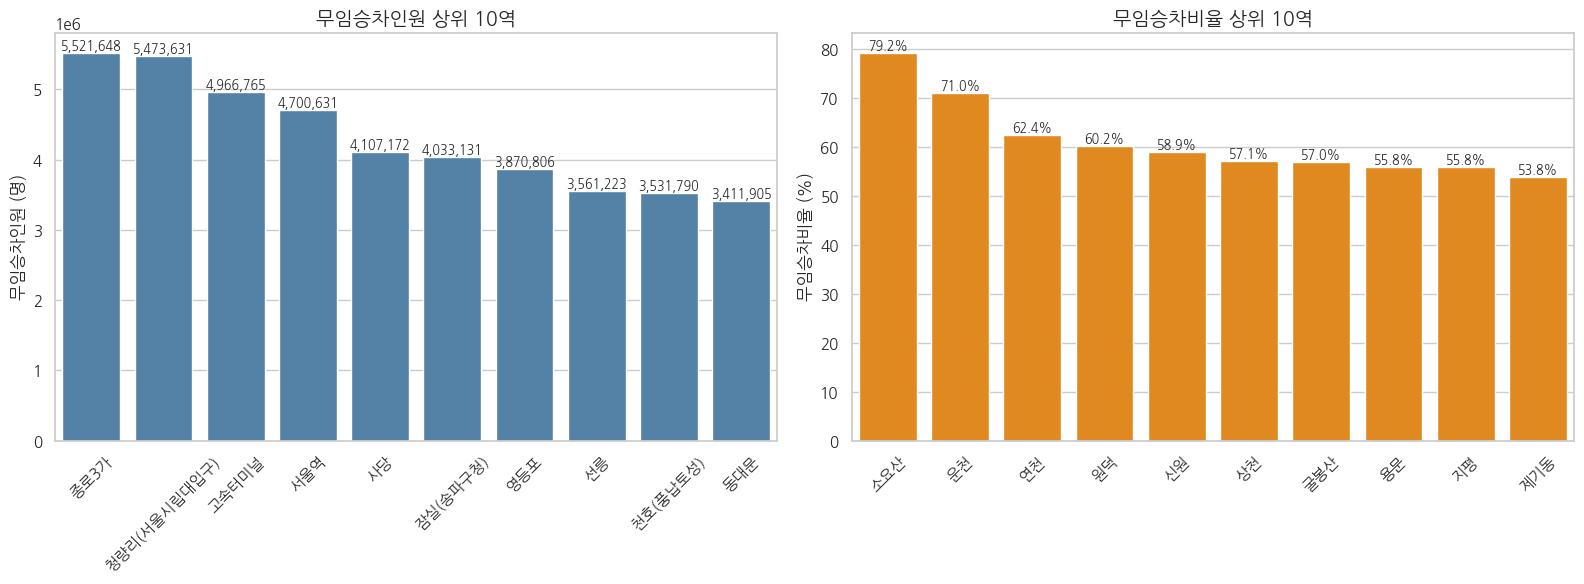

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------
# 무임승차인원 TOP10
# ------------------------
sns.barplot(
    data=top10_무임승차인원,
    x='지하철역',
    y='무임승차인원',
    color='steelblue',
    ax=axes[0]
)

axes[0].set_title('무임승차인원 상위 10역', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('무임승차인원 (명)')

axes[0].tick_params(axis='x', rotation=45)

# 값 표시
for i, v in enumerate(top10_무임승차인원['무임승차인원']):
    axes[0].text(
        i,
        v,
        f'{v:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ------------------------
# 무임승차비율 TOP10
# ------------------------
sns.barplot(
    data=top10_무임승차비율,
    x='지하철역',
    y='무임승차비율',
    color='darkorange',
    ax=axes[1]
)

axes[1].set_title('무임승차비율 상위 10역', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('무임승차비율 (%)')

axes[1].tick_params(axis='x', rotation=45)

# 값 표시
for i, v in enumerate(top10_무임승차비율['무임승차비율']):
    axes[1].text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 3-4. 전체 역의 무임승차비율과 고령인구비율 결합
- 역별 무임승차비율과 자치구별 고령인구비율을 결합하여 두 변수의 관계를 분석할 수 있도록 하였다.

In [18]:
# 전체 역별 집계 데이터프레임 생성
전체역_고령 = (
    subway_df.groupby(['지하철역', '시도', '자치구', '환승역'], dropna=False)
    .agg(
        승차인원합계=('총승차인원', 'sum'),
        무임승차인원=('무임승차인원', 'sum')
    )
    .reset_index()
)

# 무임승차비율 계산
전체역_고령['무임승차비율'] = (
    전체역_고령['무임승차인원']
    / 전체역_고령['승차인원합계']
) * 100

# 고령인구비율 merge
전체역_고령 = 전체역_고령.merge(
    고령_df[['시도', '자치구', '고령인구비율']],
    on=['시도', '자치구'],
    how='left'
)

print(f"전체 역 수: {len(전체역_고령)}개")
print(f"고령인구비율 매핑된 역: {전체역_고령['고령인구비율'].notna().sum()}개")
print(f"매핑 안 된 역: {전체역_고령['고령인구비율'].isna().sum()}개")

display(
    전체역_고령[
        ['지하철역', '시도', '자치구', '승차인원합계', '무임승차인원', '무임승차비율', '고령인구비율']
    ].head(20)
)

전체 역 수: 528개
고령인구비율 매핑된 역: 511개
매핑 안 된 역: 17개


,지하철역,시도,자치구,승차인원합계,무임승차인원,무임승차비율,고령인구비율
0,4.19민주묘지,서울특별시,강북구,1317650,500235,37.964179,27.1
1,가능,경기도,의정부시,2292266,752610,32.832577,20.7
2,가락시장,서울특별시,송파구,6201654,1885054,30.395988,18.8
3,가산디지털단지,서울특별시,금천구,19637037,1806398,9.198934,22.7
4,가양,서울특별시,강서구,7774221,1848192,23.773340,21.0
5,가오리,서울특별시,강북구,1548793,673017,43.454290,27.1
6,가좌,서울특별시,서대문구,2118994,562279,26.535186,21.0
7,가천대,경기도,성남시,3697386,368959,9.978915,19.3
8,가평,경기도,가평군,795099,234553,29.499848,34.5
9,간석,인천광역시,남동구,2024689,607101,29.984901,21.1


## 가설 A. 고령인구 비율과 무임승차 비율의 관계

### 4-1. 무임승차비율 상위·하위 20개 역 추출 (무임승차인원 중앙값 이상)
- - 무임승차인원 중앙값 이상인 역을 대상으로 무임승차비율 상위 20개 역과 하위 20개 역을 추출하였다.

In [19]:
top20_서울 = (
    역별_집계_지역[
        (역별_집계_지역['무임승차인원'] >= 중앙값_지역) &
        (역별_집계_지역['시도'] == '서울특별시')
    ]
    .sort_values('무임승차비율', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(
    top20_서울[
        ['지하철역', '시도', '자치구', '승차인원합계', '무임승차인원', '무임승차비율', '환승역']
    ]
)

,지하철역,시도,자치구,승차인원합계,무임승차인원,무임승차비율,환승역
0,제기동,서울특별시,동대문구,5874385,3159431,53.783179,False
1,도봉,서울특별시,도봉구,2080366,906364,43.567526,False
2,방학,서울특별시,도봉구,3575857,1432404,40.057642,False
3,동묘앞,서울특별시,종로구,7206213,2838819,39.394048,True
4,청량리(서울시립대입구),서울특별시,동대문구,15050598,5473631,36.368196,True
5,종로5가,서울특별시,종로구,8542065,2947067,34.500639,False
6,망우,서울특별시,중랑구,2762212,941323,34.078594,False
7,도봉산,서울특별시,도봉구,6033557,2043371,33.866772,True
8,길동,서울특별시,강동구,3202188,1073149,33.512992,False
9,불광,서울특별시,은평구,7668121,2454281,32.006289,True


In [20]:
# 하위 20개 (총승하차인원 중앙값 이상 + 무임승차비율 오름차순)
bottom20_서울 = (
    역별_집계_지역[
        (역별_집계_지역['무임승차인원'] >= 중앙값_지역) &
        (역별_집계_지역['시도'] == '서울특별시')
    ]
    .sort_values('무임승차비율', ascending=True)
    .head(20)
    .reset_index(drop=True)
)

display(
    bottom20_서울[
        ['지하철역', '시도', '자치구', '승차인원합계', '무임승차인원', '무임승차비율', '환승역']
    ]
)

,지하철역,시도,자치구,승차인원합계,무임승차인원,무임승차비율,환승역
0,홍대입구,서울특별시,마포구,34023901,1613024,4.740856,True
1,신논현,서울특별시,강남구,11209266,722897,6.449102,False
2,성수,서울특별시,성동구,18908703,1237447,6.544325,False
3,강남,서울특별시,강남구,28267447,2046396,7.239409,False
4,여의도,서울특별시,영등포구,20229539,1477905,7.305678,True
5,을지로입구,서울특별시,중구,17987363,1328527,7.385891,False
6,명동,서울특별시,중구,13621627,1061609,7.793555,False
7,삼성(무역센터),서울특별시,강남구,19068807,1514267,7.941068,False
8,합정,서울특별시,마포구,16585895,1403563,8.462389,True
9,마곡나루(서울식물원),서울특별시,강서구,9944661,854134,8.588870,True


### 4-2. 고령인구비율 결합
- 상위20개, 하위20개역 역 목록 확인 후 자치구 데이터 결합

In [21]:
# 상위 20개
top20_서울 = (
    역별_집계_지역[
        (역별_집계_지역['무임승차인원'] >= 중앙값_지역) &
        (역별_집계_지역['시도'] == '서울특별시')
    ]
    .sort_values('무임승차비율', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# 하위 20개
bottom20_서울 = (
    역별_집계_지역[
        (역별_집계_지역['무임승차인원'] >= 중앙값_지역) &
        (역별_집계_지역['시도'] == '서울특별시')
    ]
    .sort_values('무임승차비율', ascending=True)
    .head(20)
    .reset_index(drop=True)
)

print('상위 20개')
display(
    top20_서울[
        ['지하철역', '시도', '자치구', '무임승차인원', '무임승차비율', '환승역']
    ]
)

print('하위 20개')
display(
    bottom20_서울[
        ['지하철역', '시도', '자치구', '무임승차인원', '무임승차비율', '환승역']
    ]
)

상위 20개


,지하철역,시도,자치구,무임승차인원,무임승차비율,환승역
0,제기동,서울특별시,동대문구,3159431,53.783179,False
1,도봉,서울특별시,도봉구,906364,43.567526,False
2,방학,서울특별시,도봉구,1432404,40.057642,False
3,동묘앞,서울특별시,종로구,2838819,39.394048,True
4,청량리(서울시립대입구),서울특별시,동대문구,5473631,36.368196,True
5,종로5가,서울특별시,종로구,2947067,34.500639,False
6,망우,서울특별시,중랑구,941323,34.078594,False
7,도봉산,서울특별시,도봉구,2043371,33.866772,True
8,길동,서울특별시,강동구,1073149,33.512992,False
9,불광,서울특별시,은평구,2454281,32.006289,True


하위 20개


,지하철역,시도,자치구,무임승차인원,무임승차비율,환승역
0,홍대입구,서울특별시,마포구,1613024,4.740856,True
1,신논현,서울특별시,강남구,722897,6.449102,False
2,성수,서울특별시,성동구,1237447,6.544325,False
3,강남,서울특별시,강남구,2046396,7.239409,False
4,여의도,서울특별시,영등포구,1477905,7.305678,True
5,을지로입구,서울특별시,중구,1328527,7.385891,False
6,명동,서울특별시,중구,1061609,7.793555,False
7,삼성(무역센터),서울특별시,강남구,1514267,7.941068,False
8,합정,서울특별시,마포구,1403563,8.462389,True
9,마곡나루(서울식물원),서울특별시,강서구,854134,8.588870,True


### 4-3. 상·하위 20개 역의 고령인구비율과 무임승차비율 관계 분석
- 무임승차비율 상위 20개 역과 하위 20개 역을 대상으로 고령인구비율과 무임승차비율의 관계를 확인하고자 하였다.
- 두 변수의 관계를 시각적으로 살펴봄으로써, 고령인구 비율이 높은 지역에서 무임승차 이용이 어떻게 나타나는지 탐색한다.

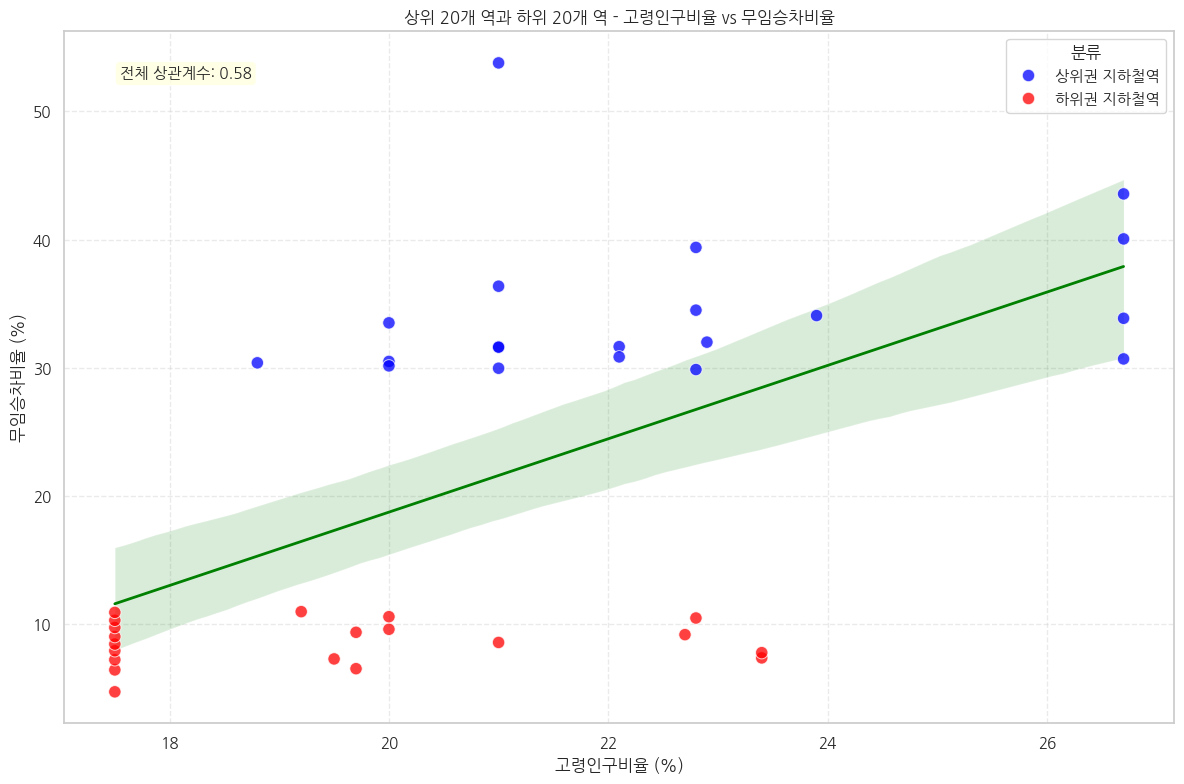

In [22]:
# 상위 20개 + 하위 20개 결합
top20_plot = top20_서울.copy()
top20_plot['분류'] = '상위권 지하철역'

bottom20_plot = bottom20_서울.copy()
bottom20_plot['분류'] = '하위권 지하철역'

상하위20_고령 = pd.concat(
    [top20_plot, bottom20_plot],
    ignore_index=True
)

# 고령인구비율 merge
상하위20_고령 = 상하위20_고령.merge(
    고령_df[['시도', '자치구', '고령인구비율']],
    on=['시도', '자치구'],
    how='left'
)

# 유효 데이터만 사용
유효_c = 상하위20_고령.dropna(
    subset=['고령인구비율', '무임승차비율']
)

# 상관계수
corr_b = 유효_c['고령인구비율'].corr(
    유효_c['무임승차비율']
)

plt.figure(figsize=(12, 8))

# 추세선 + 신뢰구간
sns.regplot(
    data=유효_c,
    x='고령인구비율',
    y='무임승차비율',
    scatter=False,
    color='green',
    line_kws={
        'linewidth': 2
    }
)

# 상위/하위 산점도
sns.scatterplot(
    data=유효_c,
    x='고령인구비율',
    y='무임승차비율',
    hue='분류',
    palette={
        '상위권 지하철역': 'blue',
        '하위권 지하철역': 'red'
    },
    s=80,
    alpha=0.75
)

plt.text(
    0.05,
    0.95,
    f'전체 상관계수: {corr_b:.2f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='lightyellow',
        alpha=0.8
    )
)

plt.title('상위 20개 역과 하위 20개 역 - 고령인구비율 vs 무임승차비율')
plt.xlabel('고령인구비율 (%)')
plt.ylabel('무임승차비율 (%)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='분류')

plt.tight_layout()
plt.show()

In [23]:
print(
    유효_c[
        ['지하철역',
         '자치구',
         '고령인구비율',
         '무임승차비율']
    ]
    .sort_values('고령인구비율')
    .to_string(index=False)
)

         지하철역  자치구  고령인구비율    무임승차비율
     삼성(무역센터)  강남구    17.5  7.941068
         홍대입구  마포구    17.5  4.740856
           신사  강남구    17.5  9.046914
           합정  마포구    17.5  8.462389
           강남  강남구    17.5  7.239409
          신논현  강남구    17.5  6.449102
          봉은사  강남구    17.5  9.754422
           역삼  강남구    17.5 10.314796
           학동  강남구    17.5 10.932991
         가락시장  송파구    18.8 30.395988
         건대입구  광진구    19.2 10.992356
          여의도 영등포구    19.5  7.305678
           성수  성동구    19.7  6.544325
           뚝섬  성동구    19.7  9.380253
           명일  강동구    20.0 30.157368
굽은다리(강동구민회관앞)  강동구    20.0 30.503369
          신용산  용산구    20.0  9.615456
           용산  용산구    20.0 10.598638
           길동  강동구    20.0 33.512992
  마곡나루(서울식물원)  강서구    21.0  8.588870
          신설동 동대문구    21.0 31.639404
          독립문 서대문구    21.0 31.613988
          제기동 동대문구    21.0 53.783179
 청량리(서울시립대입구) 동대문구    21.0 36.368196
           방화  강서구    21.0 29.972111
          수락산  노원구    22.1 30.857514
 

### 4-4. 지도 시각화 - 서울 자치구 고령인구비율 + TOP20 역 마커
- 서울 자치구의 고령인구비율과 무임승차비율 상위 20개 역의 위치를 함께 시각화하여 분포를 비교하였다.

In [24]:
import folium
import requests
import geopandas as gpd

# GeoJSON
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
geo_data = requests.get(geo_url).json()

# 서울 자치구 고령인구비율
서울_고령 = 고령_df[
    (고령_df['시도'] == '서울특별시') &
    (고령_df['자치구'] != '소계')
].reset_index(drop=True)

# 배경지도 없이 지도 생성
map_new = folium.Map(
    location=[37.5665, 126.9780],
    zoom_start=11,
    tiles=None
)

# 자치구 색상
folium.Choropleth(
    geo_data=geo_data,
    data=서울_고령,
    columns=['자치구', '고령인구비율'],
    key_on='feature.properties.name',
    fill_color='Blues',
    fill_opacity=0.85,
    line_opacity=0.8,
    line_color='white',
    legend_name='고령인구비율 (%)',
    nan_fill_color='lightgray'
).add_to(map_new)

# 자치구 중심점 자동 계산
seoul_geo = gpd.GeoDataFrame.from_features(geo_data['features'])
seoul_geo = seoul_geo.set_crs(epsg=4326)

seoul_geo_5179 = seoul_geo.to_crs(epsg=5179)
seoul_geo_5179['중심점'] = seoul_geo_5179.geometry.centroid

centroid_gdf = gpd.GeoDataFrame(
    seoul_geo_5179[['name']],
    geometry=seoul_geo_5179['중심점'],
    crs=seoul_geo_5179.crs
).to_crs(epsg=4326)

구_좌표 = {
    row['name']: [row.geometry.y, row.geometry.x]
    for _, row in centroid_gdf.iterrows()
}

# ==========================
# TOP10 역 마커 먼저 추가
# ==========================
for _, row in top20_위치.iterrows():

    역명 = row['역이름']
    lat = row['위도']
    lng = row['경도']

    역_정보 = top20_서울[top20_서울['지하철역'] == 역명]

    if not 역_정보.empty:

        무임 = int(역_정보['무임승차인원'].values[0])
        비율 = round(역_정보['무임승차비율'].values[0], 1)

        popup_text = (
            f'<b>{역명}</b><br>'
            f'무임승차인원: {무임:,}명<br>'
            f'무임승차비율: {비율}%'
        )

    else:
        popup_text = f'<b>{역명}</b>'

    folium.Marker(
        location=[lat, lng],
        popup=folium.Popup(popup_text, max_width=200),
        tooltip=f'🚇 {역명}',
        icon=folium.Icon(
            color='red',
            icon='info-sign'
        )
    ).add_to(map_new)

# ==========================
# 자치구 라벨은 마지막에 추가
# ==========================
for _, row in 서울_고령.iterrows():

    자치구명 = row['자치구']

    if 자치구명 not in 구_좌표:
        continue

    folium.Marker(
        location=구_좌표[자치구명],
        icon=folium.DivIcon(
            html=f'''
            <div style="
                font-size:12px;
                font-weight:bold;
                color:black;
                text-align:center;
                line-height:1.2;
                white-space:nowrap;">
                {자치구명}<br>{row["고령인구비율"]:.1f}%
            </div>
            ''',
            icon_size=(80, 30),
            icon_anchor=(40, 15),
            class_name='empty'
        )
    ).add_to(map_new)

map_new

### 가설 A 결과 해석

- 무임승차 집중 상위·하위 20역의 고령인구 비율과 무임승차비율 간에는 상관계수 0.58의 양의 상관관계가 나타났으며, 고령인구 비율이 높은 지역일수록 무임승차비율도 높아지는 경향을 보였다.
- 무임승차 집중 상위 20역은 주로 서울 북부 및 외곽의 고령인구 비율이 높은 자치구에 분포하여 고령화와 무임승차 이용 간의 관련성을 확인할 수 있었다.

## 가설 A-1. 무임승차 집중역 근처 경로당 수 분석

### 5-1. 무임승차비율 상위역 차출

In [25]:
# 역별 집계 (합산 후 비율 계산)
역별_집계 = (
    subway_df.groupby(['지하철역', '환승역'])
    .agg(
        승차인원합계=('총승차인원', 'sum'),
        무임승차인원=('무임승차인원', 'sum')
    )
    .reset_index()
)

# 합산 후 비율 계산
역별_집계['무임승차비율'] = (역별_집계['무임승차인원'] / 역별_집계['승차인원합계']) * 100

# 중앙값 계산
중앙값 = 역별_집계['무임승차인원'].median()
print(f'전체 역 무임승차인원 중앙값: {중앙값:.4f}')

전체 역 무임승차인원 중앙값: 720370.5000


In [26]:
# 무임승차비율 내림차순 정렬 후 무임승차인원이 중앙값 이상인 역 TOP35
top35 = (
    역별_집계[역별_집계['무임승차인원'] >= 중앙값]
    .sort_values('무임승차비율', ascending=False)
    .head(35)
    .reset_index(drop=True)
)

display(top35[['지하철역', '승차인원합계', '무임승차인원', '무임승차비율', '환승역']])

,지하철역,승차인원합계,무임승차인원,무임승차비율,환승역
0,제기동,5874385,3159431,53.783179,False
1,경마공원,2023531,1007406,49.784560,False
2,도봉,2080366,906364,43.567526,False
3,회룡,4700272,2013198,42.831521,False
4,온양온천,1843232,765865,41.550114,False
5,방학,3575857,1432404,40.057642,False
6,동묘앞,7206213,2838819,39.394048,True
7,소래포구,1933765,726591,37.573904,False
8,주엽,3186023,1191708,37.404250,False
9,청량리(서울시립대입구),15050598,5473631,36.368196,True


### 5-2. 무임승차비율 하위역 차출

In [27]:
# 무임승차인원 오름차순 정렬 후 중앙값 이상인 역 TOP20
bottom20 = (
    역별_집계[역별_집계['무임승차인원'] >= 중앙값]
    .sort_values('무임승차비율', ascending=True)
    .head(20)
    .reset_index(drop=True)
)

display(bottom20[['지하철역', '승차인원합계', '무임승차인원', '무임승차비율', '환승역']])

,지하철역,승차인원합계,무임승차인원,무임승차비율,환승역
0,홍대입구,34023901,1613024,4.740856,True
1,신논현,11209266,722897,6.449102,False
2,성수,18908703,1237447,6.544325,False
3,강남,28267447,2046396,7.239409,False
4,여의도,20229539,1477905,7.305678,True
5,을지로입구,17987363,1328527,7.385891,False
6,명동,13621627,1061609,7.793555,False
7,삼성(무역센터),19068807,1514267,7.941068,False
8,합정,16585895,1403563,8.462389,True
9,마곡나루(서울식물원),9944661,854134,8.588870,True


### 5-3. 상·하위 20개 역 중 서울 지역 지하철역 추출
- 수도권 상·하위 20개 역 중 서울특별시에 위치한 역만 선별하여 후속 분석에 활용하였다.

In [28]:
# 이후 외부에서 상위/하위 역의 경도, 위도를 추가해서 CSV 파일로 저장하기 위한 과정

# 역별 시도, 자치구 정보 가져오기
역별_지역정보 = (
    subway_df[['지하철역', '시도', '자치구']]
    .drop_duplicates(subset=['지하철역'])
)

# top35에 시도, 자치구 추가
top35_지역 = top35.merge(
    역별_지역정보,
    on='지하철역',
    how='left'
)

# bottom20에 시도, 자치구 추가
bottom20_지역 = bottom20.merge(
    역별_지역정보,
    on='지하철역',
    how='left'
)

# top35 중 서울특별시에 있는 역만 추출
top20_서울_5 = (
    top35_지역[top35_지역['시도'] == '서울특별시']
    .head(20)
    .reset_index(drop=True)
)

# bottom20 중 서울특별시에 있는 역만 추출
bottom20_서울_5 = (
    bottom20_지역[bottom20_지역['시도'] == '서울특별시']
    .head(20)
    .reset_index(drop=True)
)

print('상위 후보 역 중 서울특별시에 있는 역')
display(top20_서울_5[
    ['지하철역', '시도', '자치구', '승차인원합계', '무임승차인원', '무임승차비율', '환승역']
])

print('하위 후보 역 중 서울특별시에 있는 역')
display(bottom20_서울_5[
    ['지하철역', '시도', '자치구', '승차인원합계', '무임승차인원', '무임승차비율', '환승역']
])

print(f'상위 후보 중 서울 역 개수: {len(top20_서울_5)}개')
print(f'하위 후보 중 서울 역 개수: {len(bottom20_서울_5)}개')

# 이후 외부에서 상위 하위 역의 20개역의 경도 위도를 추가해서 csv 파일로 저장

상위 후보 역 중 서울특별시에 있는 역


,지하철역,시도,자치구,승차인원합계,무임승차인원,무임승차비율,환승역
0,제기동,서울특별시,동대문구,5874385,3159431,53.783179,False
1,도봉,서울특별시,도봉구,2080366,906364,43.567526,False
2,방학,서울특별시,도봉구,3575857,1432404,40.057642,False
3,동묘앞,서울특별시,종로구,7206213,2838819,39.394048,True
4,청량리(서울시립대입구),서울특별시,동대문구,15050598,5473631,36.368196,True
5,종로5가,서울특별시,종로구,8542065,2947067,34.500639,False
6,망우,서울특별시,중랑구,2762212,941323,34.078594,False
7,도봉산,서울특별시,도봉구,6033557,2043371,33.866772,True
8,길동,서울특별시,강동구,3202188,1073149,33.512992,False
9,불광,서울특별시,은평구,7668121,2454281,32.006289,True


하위 후보 역 중 서울특별시에 있는 역


,지하철역,시도,자치구,승차인원합계,무임승차인원,무임승차비율,환승역
0,홍대입구,서울특별시,마포구,34023901,1613024,4.740856,True
1,신논현,서울특별시,강남구,11209266,722897,6.449102,False
2,성수,서울특별시,성동구,18908703,1237447,6.544325,False
3,강남,서울특별시,강남구,28267447,2046396,7.239409,False
4,여의도,서울특별시,영등포구,20229539,1477905,7.305678,True
5,을지로입구,서울특별시,중구,17987363,1328527,7.385891,False
6,명동,서울특별시,중구,13621627,1061609,7.793555,False
7,삼성(무역센터),서울특별시,강남구,19068807,1514267,7.941068,False
8,합정,서울특별시,마포구,16585895,1403563,8.462389,True
9,마곡나루(서울식물원),서울특별시,강서구,9944661,854134,8.588870,True


상위 후보 중 서울 역 개수: 20개
하위 후보 중 서울 역 개수: 20개


### 5-4. 노인복지시설 및 상·하위 지하철역 위치정보 결합
- 외부에서 수집한 위도·경도 데이터를 활용하여 노인복지시설과 상·하위 지하철역의 위치정보를 결합하였다.

In [29]:
# 파일 불러오기
top_subway_df = pd.read_csv(top_subway_file)
bottoom_subway_df = pd.read_csv(bottom_subway_file)
welfare_df = pd.read_csv(welfare_file)

# 데이터 확인
print("--- 상위권 지하철 데이터 ---")
display(top_subway_df.head(2))
print("--- 하위권 지하철 데이터 ---")
display(bottoom_subway_df.head(2))
print("--- 복지시설 데이터 ---")
display(welfare_df.head(2))

--- 상위권 지하철 데이터 ---


,역이름,위도,경도
0,제기동,37.578113,127.034813
1,도봉,37.679572,127.045053


--- 하위권 지하철 데이터 ---


,역이름,위도,경도
0,홍대입구,37.557527,126.924466
1,신논현,37.504598,127.025060


--- 복지시설 데이터 ---


,시설명,위도,경도
0,둔촌푸르지오A,37.534694,127.146777
1,한솔솔파크,37.534076,127.148206


### 5-5. 상위권 지하철역 주변 500m 내 노인복지시설 분포 분석

In [30]:
# 위경도 좌표를 지도 위의 점 데이터로 변환 (기본 위경도 좌표계: EPSG:4326)
subway_gdf_500m = gpd.GeoDataFrame(
    top_subway_df,
    geometry=gpd.points_from_xy(top_subway_df['경도'], top_subway_df['위도']),
    crs="EPSG:4326"
)

welfare_gdf = gpd.GeoDataFrame(
    welfare_df,
    geometry=gpd.points_from_xy(welfare_df['경도'], welfare_df['위도']),
    crs="EPSG:4326"
)

# 미터(m) 단위로 거리를 계산하기 위해 한국 공용 투영좌표계로 변환 (EPSG:5179)
subway_gdf_500m = subway_gdf_500m.to_crs(epsg=5179)

# welfare_gdf도 동일한 CRS로 변환하여 CRS 불일치 문제 해결
welfare_gdf = welfare_gdf.to_crs(epsg=5179)

# 지하철역 점 주변으로 500m 반경 원(Buffer) 영역 생성
subway_gdf_500m['buffer_500m'] = subway_gdf_500m.geometry.buffer(500)

# 공간 조인(Spatial Join)을 위해 기준 geometry를 방금 만든 원(폴리곤)으로 설정
subway_buffer_gdf_500m = subway_gdf_500m.set_geometry('buffer_500m')

# 500m 원 안에 들어오는 복지시설 점들을 매칭 (within: 포함 관계)
joined_500m = gpd.sjoin(welfare_gdf, subway_buffer_gdf_500m, how='inner', predicate='within')

# 지하철역별로 매칭된 복지시설 개수 집계
result_500m = joined_500m.groupby('역이름').size().reset_index(name='노인복지시설_개수')

# 복지시설이 0개인 역도 누락되지 않도록 최종 결합
final_result_500m = pd.merge(top_subway_df[['역이름']], result_500m, on='역이름', how='left').fillna(0)
final_result_500m['노인복지시설_개수'] = final_result_500m['노인복지시설_개수'].astype(int)

# 엑셀(Excel)에서 열었을 때 한글이 깨지지 않도록 인코딩하여 CSV로 저장
output_file_500m = 'subway_welfare_count_500m.csv'
final_result_500m.to_csv(output_file_500m, index=False, encoding='utf-8-sig')

display(final_result_500m)

,역이름,노인복지시설_개수
0,제기동,8
1,도봉,9
2,방학,10
3,동묘앞,7
4,청량리(서울시립대입구),5
5,종로5가,3
6,망우,6
7,도봉산,4
8,길동,8
9,불광,4


### 5-6. 하위권 지하철역 주변 500m 내 노인복지시설 분포 분석

In [31]:
# 위경도 좌표를 지도 위의 점(Geometry) 데이터로 변환 (기본 위경도 좌표계: EPSG:4326)
subway_gdf_bottom_500m = gpd.GeoDataFrame(
    bottoom_subway_df,
    geometry=gpd.points_from_xy(bottoom_subway_df['경도'], bottoom_subway_df['위도']),
    crs="EPSG:4326"
)

# 미터(m) 단위로 거리를 계산하기 위해 한국 공용 투영좌표계로 변환 (EPSG:5179)
subway_gdf_bottom_500m = subway_gdf_bottom_500m.to_crs(epsg=5179)

# 지하철역 점 주변으로 500m 반경 원(Buffer) 영역 생성
subway_gdf_bottom_500m['buffer_500m'] = subway_gdf_bottom_500m.geometry.buffer(500)

# 공간 조인(Spatial Join)을 위해 기준 geometry를 방금 만든 원(폴리곤)으로 설정
subway_buffer_gdf_bottom_500m = subway_gdf_bottom_500m.set_geometry('buffer_500m')

# 500m 원 안에 들어오는 복지시설 점들을 매칭 (within: 포함 관계)
joined_bottom_500m = gpd.sjoin(welfare_gdf, subway_buffer_gdf_bottom_500m, how='inner', predicate='within')

# 지하철역별로 매칭된 복지시설 개수 집계
result_bottom_500m = joined_bottom_500m.groupby('역이름').size().reset_index(name='노인복지시설_개수')

# 복지시설이 0개인 역도 누락되지 않도록 최종 결합
final_result_bottom_500m = pd.merge(bottoom_subway_df[['역이름']], result_bottom_500m, on='역이름', how='left').fillna(0)
final_result_bottom_500m['노인복지시설_개수'] = final_result_bottom_500m['노인복지시설_개수'].astype(int)

display(final_result_bottom_500m)

,역이름,노인복지시설_개수
0,홍대입구,2
1,신논현,3
2,성수,8
3,강남,1
4,여의도,3
5,을지로입구,0
6,명동,1
7,삼성(무역센터),0
8,합정,1
9,마곡나루(서울식물원),4


### 5-7. 서울 지역 지하철역의 500m 반경 분석 결과 결합

In [32]:
# 서울지역이 아닌 역 제외 (500m)
final_result_filtered_for_plot_500m = final_result_500m.copy()
final_result_bottom_filtered_for_plot_500m = final_result_bottom_500m.copy()

# Rename '역이름' to '지하철역' in both dataframes for consistent merging
final_result_filtered_for_plot_500m = final_result_filtered_for_plot_500m.rename(columns={'역이름': '지하철역'})
final_result_bottom_filtered_for_plot_500m = final_result_bottom_filtered_for_plot_500m.rename(columns={'역이름': '지하철역'})

# Add '분류' column
final_result_filtered_for_plot_500m['분류'] = '상위권 지하철역'
final_result_bottom_filtered_for_plot_500m['분류'] = '하위권 지하철역'

# Merge '무임승차비율' from 전체역_고령 into both dataframes
final_result_filtered_for_plot_500m = pd.merge(
    final_result_filtered_for_plot_500m,
    전체역_고령[['지하철역', '무임승차비율']],
    on='지하철역',
    how='left'
)

final_result_bottom_filtered_for_plot_500m = pd.merge(
    final_result_bottom_filtered_for_plot_500m,
    전체역_고령[['지하철역', '무임승차비율']],
    on='지하철역',
    how='left'
)

# Concatenate the filtered results
combined_results_filtered_500m = pd.concat([final_result_filtered_for_plot_500m, final_result_bottom_filtered_for_plot_500m], ignore_index=True)

# 노인복지시설 개수의 평균 계산
average_welfare_count_500m = combined_results_filtered_500m['노인복지시설_개수'].mean()

# Drop rows where '무임승차비율' is NaN, as these stations don't have this data
combined_results_filtered_500m.dropna(subset=['무임승차비율'], inplace=True)

### 5-8. 노인복지시설 분포와 무임승차비율 관계 시각화

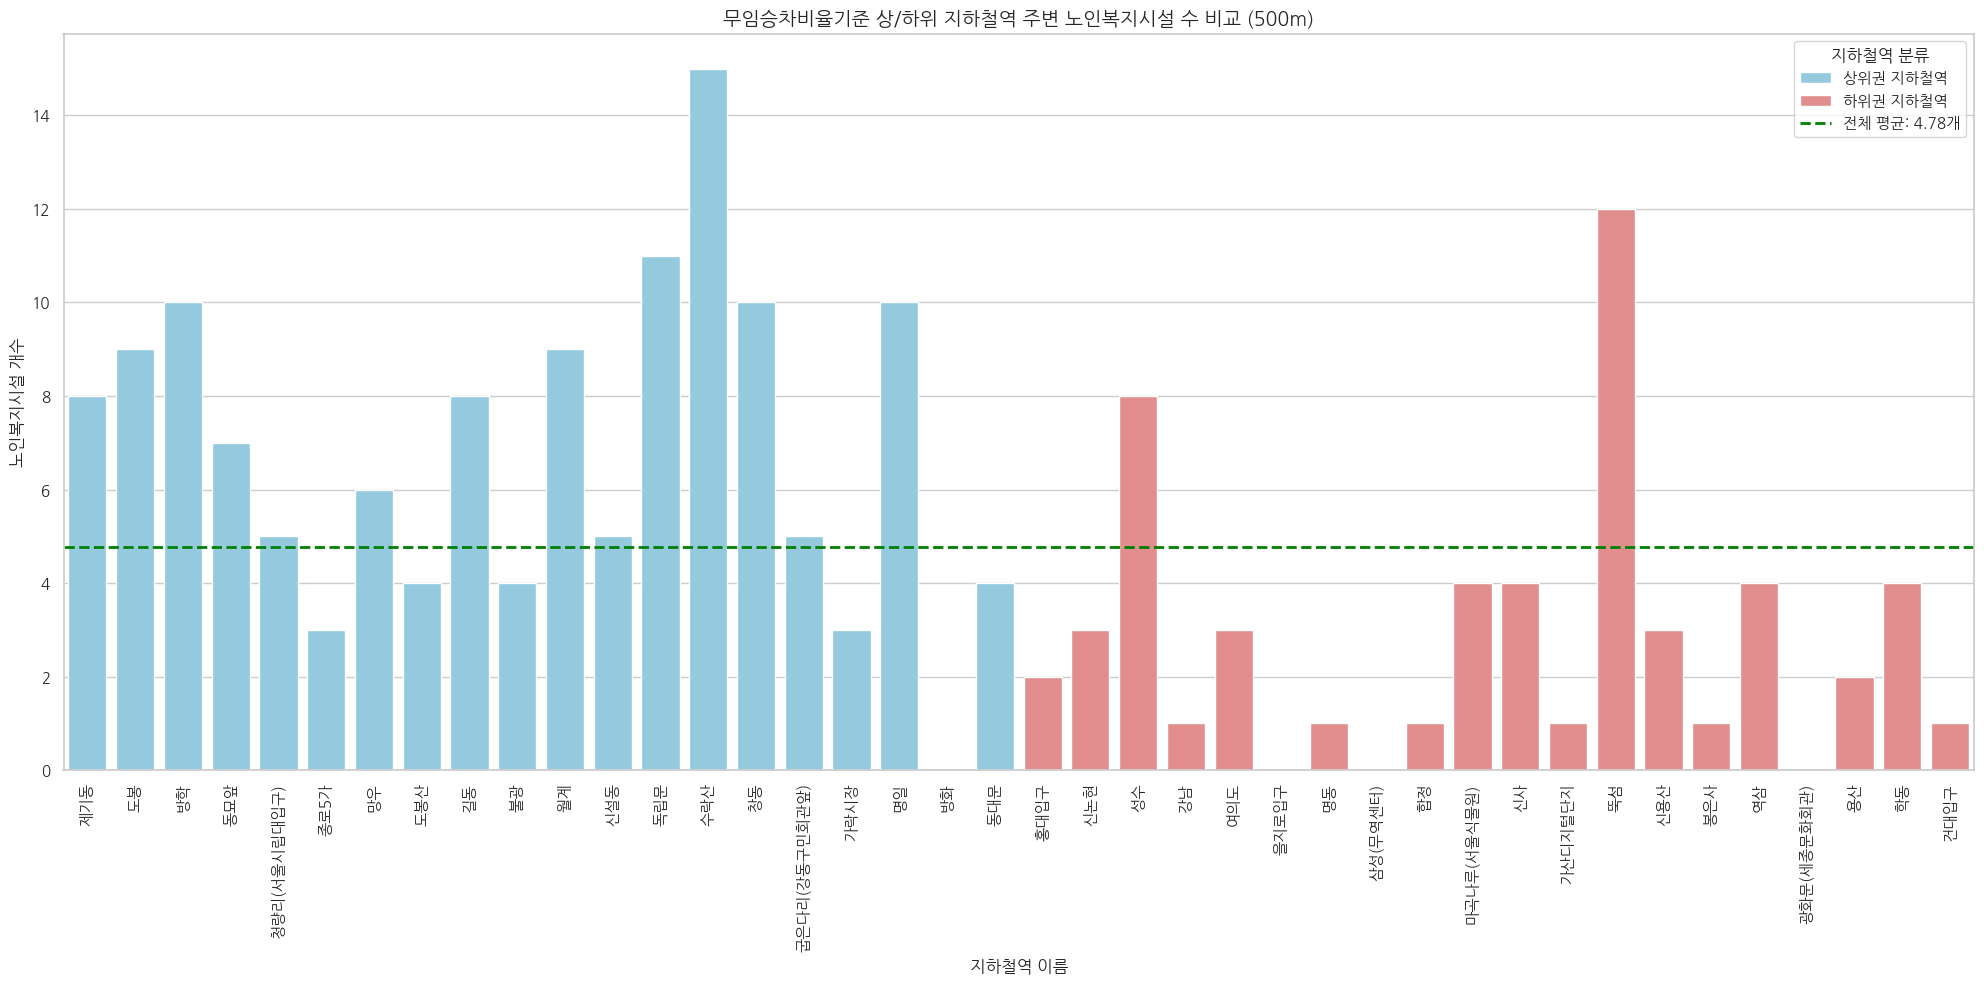

In [33]:
plt.figure(figsize=(20, 10))
sns.barplot(
    x='지하철역',
    y='노인복지시설_개수',
    hue='분류',
    data=combined_results_filtered_500m,
    palette={'상위권 지하철역': 'skyblue', '하위권 지하철역': 'lightcoral'}
)
plt.axhline(average_welfare_count_500m, color='green', linestyle='--', linewidth=2, label=f'전체 평균: {average_welfare_count_500m:.2f}개')
plt.xticks(rotation=90)
plt.xlabel('지하철역 이름', fontsize=12)
plt.ylabel('노인복지시설 개수', fontsize=12)
plt.title('무임승차비율기준 상/하위 지하철역 주변 노인복지시설 수 비교 (500m)', fontsize=14)
plt.legend(title='지하철역 분류')
plt.tight_layout()
plt.show()

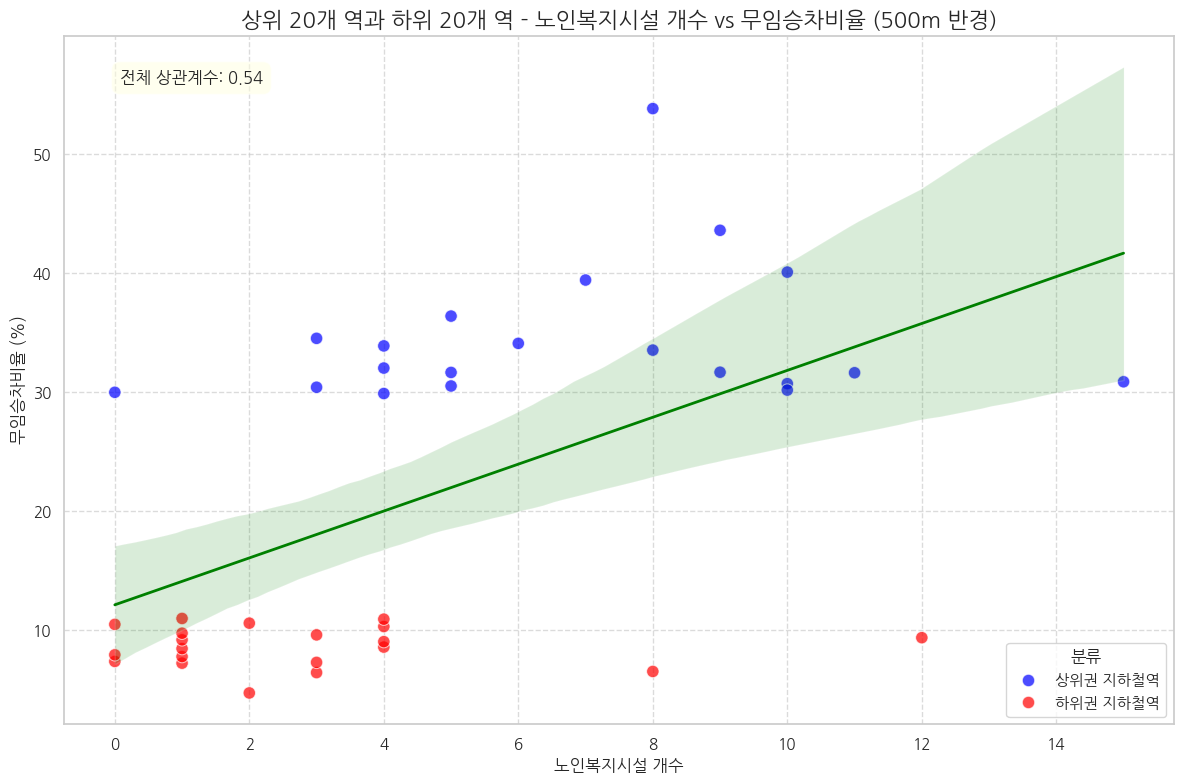

In [34]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='노인복지시설_개수',
    y='무임승차비율',
    hue='분류', # Still use hue to differentiate the two groups visually
    data=combined_results_filtered_500m,
    palette={'상위권 지하철역': 'blue', '하위권 지하철역': 'red'},
    s=80,
    alpha=0.7,
    legend='full'
)

# Add a single regression line for the combined data
sns.regplot(
    x='노인복지시설_개수',
    y='무임승차비율',
    data=combined_results_filtered_500m,
    scatter=False, # Do not plot scatter points again
    line_kws={'color':'green', 'linestyle':'-', 'linewidth': 2},
    ax=plt.gca() # Plot on the current axes
)

plt.title('상위 20개 역과 하위 20개 역 - 노인복지시설 개수 vs 무임승차비율 (500m 반경)', fontsize=16)
plt.xlabel('노인복지시설 개수', fontsize=12)
plt.ylabel('무임승차비율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Calculate and display the single correlation for the combined data
correlation_combined = combined_results_filtered_500m['노인복지시설_개수'].corr(combined_results_filtered_500m['무임승차비율'])

plt.text(
    0.05, 0.95,
    f'전체 상관계수: {correlation_combined:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', alpha=0.5, fc='lightyellow')
)

plt.tight_layout()
plt.show()

### 가설 A-1 결과 해석

- 무임승차 집중 상위 20역의 500m 반경 내 노인복지시설 수는 평균 6.8개로, 하위 20역의 평균 2.75개보다 약 2.5배 높게 나타났다.
- 노인복지시설 수와 무임승차비율의 상관계수는 0.54로 나타났으며, 두 변수 간 중간 수준의 양의 상관관계가 확인되었다.

## 가설 A-2.  노인 이용자의 이용패턴 분석

### 6-1. 노인 이용패턴 분석을 위한 무임승차비율 상위 10개 역 선정
- 노인 이용자의 시간대별 이용패턴을 분석하기 위해 무임승차비율이 높은 상위 10개 역을 선정하였다.

In [35]:
top10_비율 = (
    전체역_고령
    .sort_values('무임승차비율', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_역명 = top10_비율['지하철역'].tolist()
print('TOP10 역:', top10_역명)

TOP10 역: ['소요산', '운천', '연천', '원덕', '신원', '상천', '굴봉산', '용문', '지평', '제기동']


### 6-2. TOP10 역 시간대별 집계

In [36]:
# 승차만 필터
노인_승차 = 노인_df[노인_df['승하차구분'] == '승차'].copy()

# 역별 시간대 합산
역별_시간대 = (
    노인_승차.groupby('역명')[시간대_컬럼]
    .sum()
    .reset_index()
)

# 4구간 컬럼 추가
for 그룹명, 컬럼들 in 시간대_그룹.items():
    역별_시간대[그룹명] = 역별_시간대[컬럼들].sum(axis=1)

그룹_컬럼 = list(시간대_그룹.keys())

# TOP10 필터 (역명 일치 확인)
top10_시간대 = 역별_시간대[역별_시간대['역명'].isin(top10_역명)].copy()
print(f'매핑된 역 수: {len(top10_시간대)}개 / {len(top10_역명)}개')
print('매핑 안 된 역:', set(top10_역명) - set(top10_시간대['역명'].tolist()))

매핑된 역 수: 1개 / 10개
매핑 안 된 역: {'원덕', '소요산', '운천', '연천', '지평', '상천', '신원', '용문', '굴봉산'}


### 6-3. 시각화 ① - 노인 승객의 시간대별 이용패턴 분석

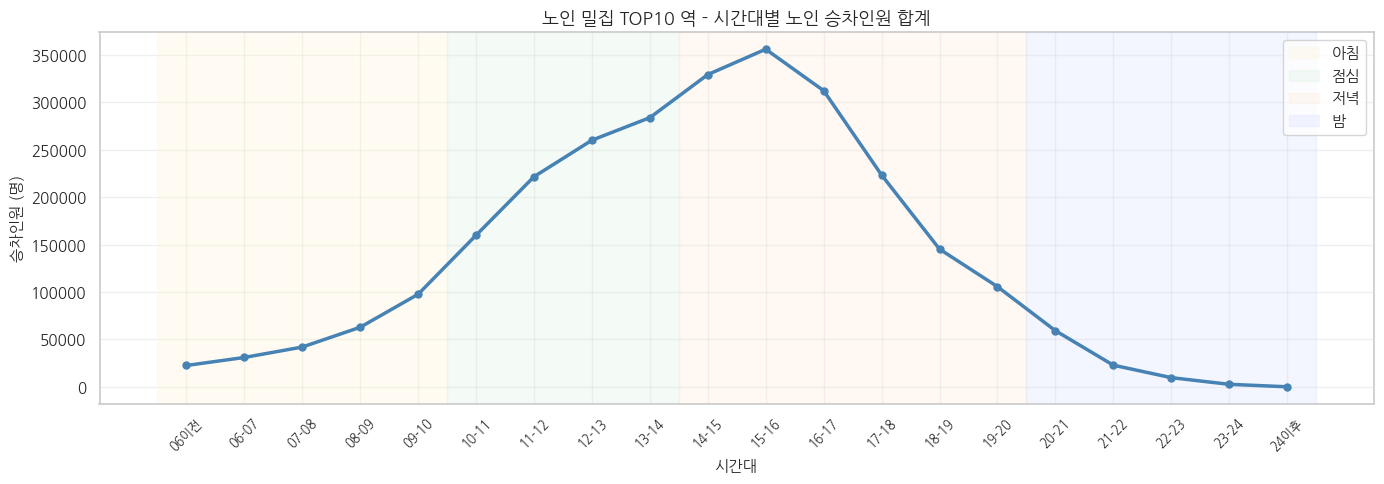

In [37]:
# 시간대별 전체 합산 (TOP10 역)
시간대_합계 = top10_시간대[시간대_컬럼].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(시간대_컬럼)), 시간대_합계.values,
        color='steelblue', linewidth=2.5, marker='o', markersize=5)

# 4구간 배경색
구간_범위 = {
    '아침': (0, 4, '#FFF3CD'),
    '점심': (5, 8, '#D4EDDA'),
    '저녁': (9, 14, '#FFE5D0'),
    '밤':   (15, 19, '#D0D8FF')
}
for 이름, (시작, 끝, 색) in 구간_범위.items():
    ax.axvspan(시작 - 0.5, 끝 + 0.5, alpha=0.25, color=색, label=이름)

ax.set_xticks(range(len(시간대_컬럼)))
ax.set_xticklabels([c.replace('시간대', '').replace('이전', '이전').replace('이후', '이후')
                    for c in 시간대_컬럼], rotation=45, fontsize=9)
ax.set_title('노인 밀집 TOP10 역 - 시간대별 노인 승차인원 합계', fontsize=13)
ax.set_xlabel('시간대', fontsize=11)
ax.set_ylabel('승차인원 (명)', fontsize=11)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6-4. 시각화 ② - 시간대 구간별 노인 승차인원 및 이용 비중

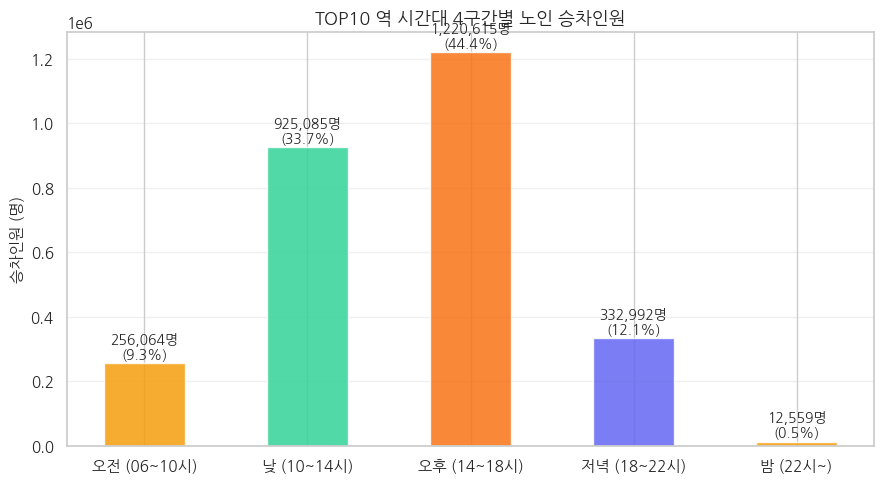


=== 시간대별 비율 ===
오전 (06~10시): 256,064명 (9.3%)
낮 (10~14시): 925,085명 (33.7%)
오후 (14~18시): 1,220,615명 (44.4%)
저녁 (18~22시): 332,992명 (12.1%)
밤 (22시~): 12,559명 (0.5%)


In [38]:
top10_시간대_set = top10_시간대.set_index('역명')
합산 = top10_시간대_set[그룹_컬럼].sum()
총합 = 합산.sum()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F59E0B', '#34D399', '#F97316', '#6366F1']
bars = ax.bar(
    [c.replace('\n', ' ') for c in 그룹_컬럼],
    합산.values,
    color=colors, alpha=0.85, width=0.5
)

for bar, val in zip(bars, 합산.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 총합 * 0.005,
            f'{val:,.0f}명\n({val/총합*100:.1f}%)',
            ha='center', fontsize=10)

ax.set_title('TOP10 역 시간대 4구간별 노인 승차인원', fontsize=13)
ax.set_ylabel('승차인원 (명)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\n=== 시간대별 비율 ===')
for 그룹, 값 in 합산.items():
    print(f'{그룹.replace(chr(10), " ")}: {값:,.0f}명 ({값/총합*100:.1f}%)')

In [39]:
구별_역수 = (
    전체역_고령[전체역_고령['자치구'].isin(['강북구', '도봉구'])]
    .groupby('자치구')['지하철역']
    .count()
    .reset_index()
    .rename(columns={'지하철역': '역수'})
)

display(구별_역수)

,자치구,역수
0,강북구,11
1,도봉구,6


In [40]:
# 강북구, 도봉구 안에 있는 역 필터링
강북_도봉_역 = 전체역_고령[
    전체역_고령['자치구'].isin(['강북구', '도봉구'])
].copy()

# 무임승차비율 TOP10
top10_강북도봉 = (
    강북_도봉_역
    .sort_values('승차인원합계', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top10_강북도봉[['지하철역', '자치구', '승차인원합계', '무임승차인원', '무임승차비율']])

,지하철역,자치구,승차인원합계,무임승차인원,무임승차비율
0,수유(강북구청),강북구,12170667,2452655,20.152182
1,쌍문,도봉구,10299767,2314402,22.470431
2,창동,도봉구,9735673,2988818,30.699655
3,미아사거리,강북구,9291783,2376096,25.572013
4,도봉산,도봉구,6033557,2043371,33.866772
5,미아(서울사이버대학),강북구,5694023,1550894,27.237228
6,방학,도봉구,3575857,1432404,40.057642
7,도봉,도봉구,2080366,906364,43.567526
8,솔샘,강북구,2079035,537396,25.848338
9,가오리,강북구,1548793,673017,43.454290


In [41]:
타겟_역 = ['미아사거리', '수유(강북구청)', '쌍문', '창동']

타겟_시간대 = 역별_시간대[
    역별_시간대['역명'].isin(타겟_역)
].copy()

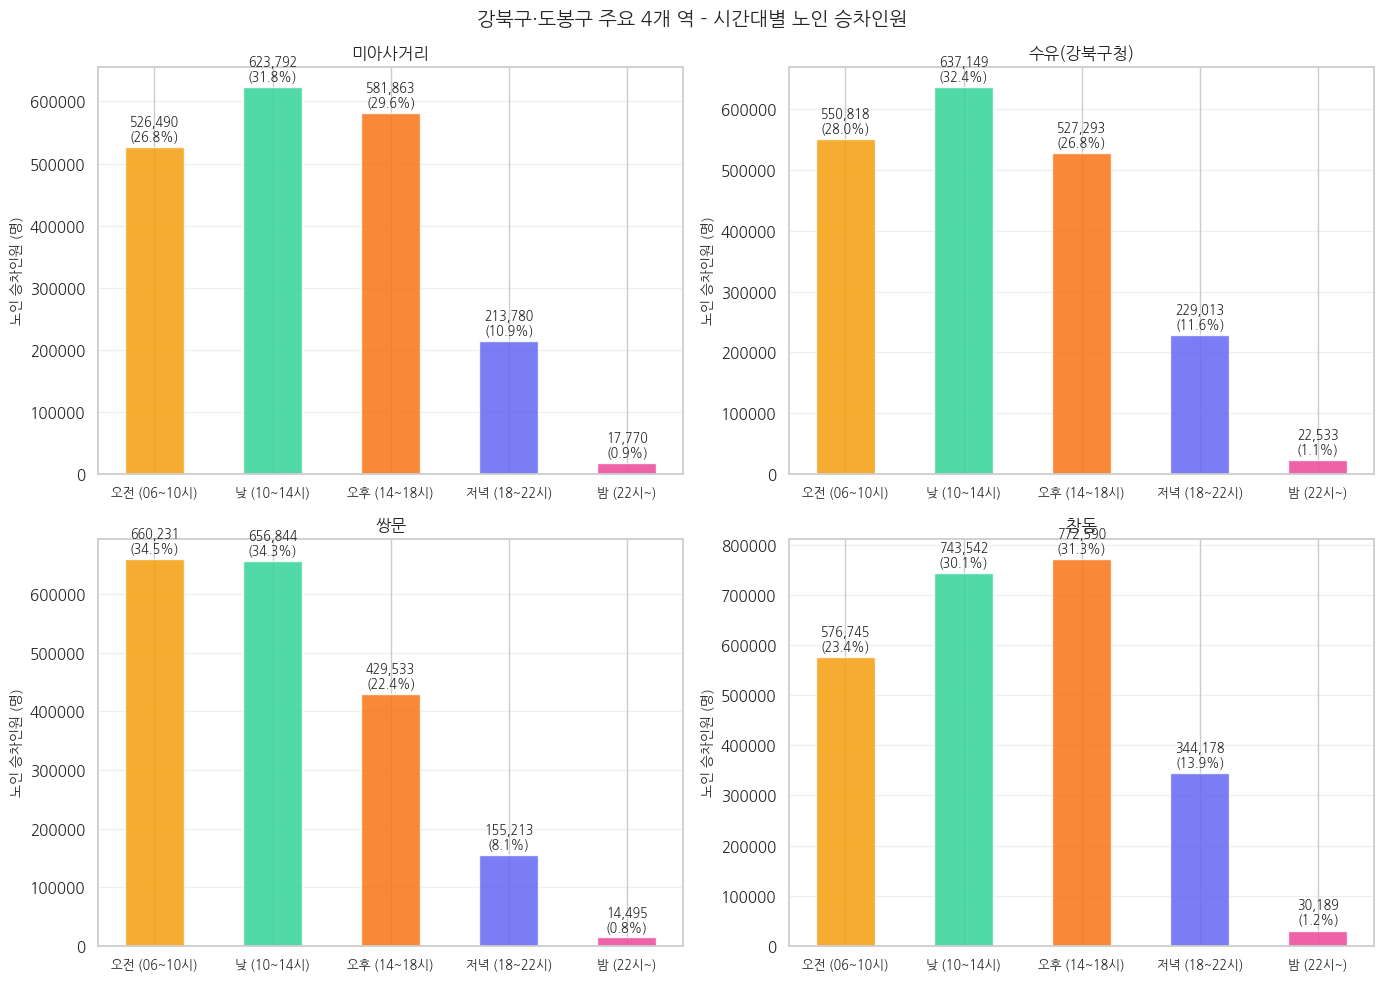

In [42]:
그룹_컬럼 = list(시간대_그룹.keys())
타겟_시간대_set = 타겟_시간대.set_index('역명')

# 4구간 합산
for 그룹명, 컬럼들 in 시간대_그룹.items():
    타겟_시간대_set[그룹명] = 타겟_시간대_set[컬럼들].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#F59E0B', '#34D399', '#F97316', '#6366F1', '#EC4899']

for i, 역 in enumerate(['미아사거리', '수유(강북구청)', '쌍문', '창동']):
    ax = axes[i]
    데이터 = 타겟_시간대_set.loc[역, 그룹_컬럼]
    총합 = 데이터.sum()

    bars = ax.bar(
        [c.replace('\n', ' ') for c in 그룹_컬럼],
        데이터.values,
        color=colors[:len(그룹_컬럼)],
        alpha=0.85,
        width=0.5
    )

    for bar, val in zip(bars, 데이터.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 총합 * 0.005,
            f'{val:,.0f}\n({val/총합*100:.1f}%)',
            ha='center', fontsize=9
        )

    ax.set_title(f'{역}', fontsize=12, fontweight='bold')
    ax.set_ylabel('노인 승차인원 (명)', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('강북구·도봉구 주요 4개 역 - 시간대별 노인 승차인원', fontsize=14)
plt.tight_layout()
plt.show()

### 6-5. 강북구·도봉구 4개 역의 시간대별 노인 승차인원 비교
- 서울 내 고령인구비율이 높은 강북구·도봉구의 주요 역을 선정하여 노인 이용자의 시간대별 이용 특성을 비교하였다.

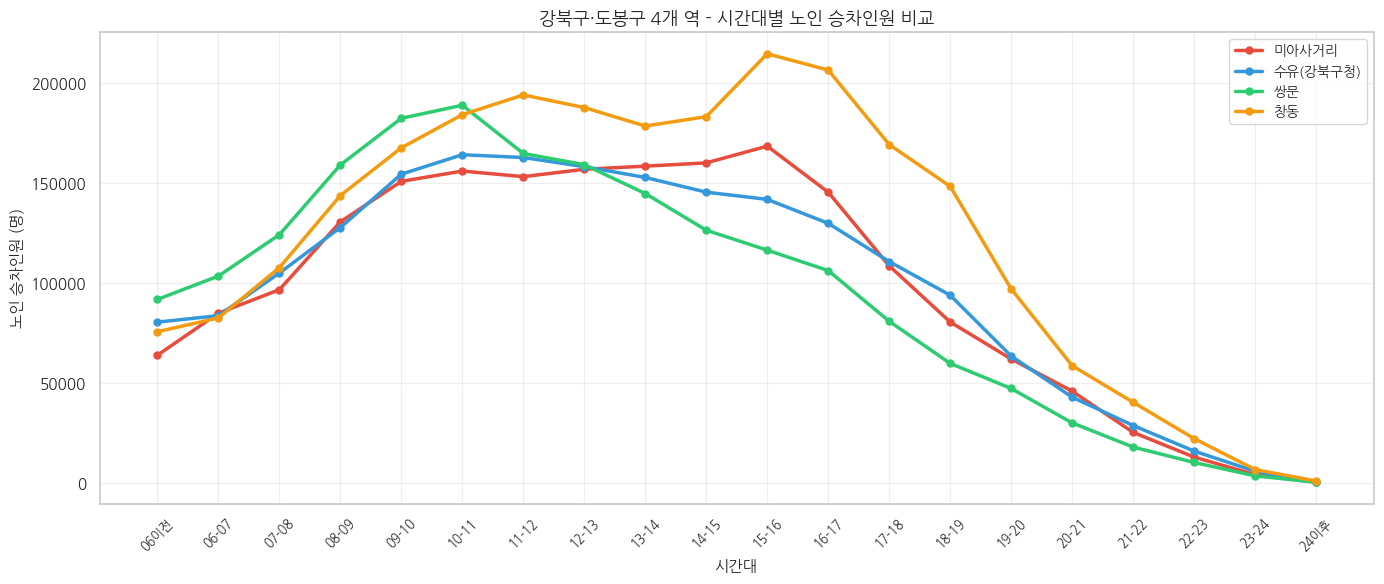

In [43]:

fig, ax = plt.subplots(figsize=(14, 6))

line_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

for i, 역 in enumerate(['미아사거리', '수유(강북구청)', '쌍문', '창동']):
    데이터 = 타겟_시간대_set.loc[역, 시간대_컬럼]
    ax.plot(range(len(시간대_컬럼)), 데이터.values,
            color=line_colors[i], linewidth=2.5,
            marker='o', markersize=5, label=역)

ax.set_xticks(range(len(시간대_컬럼)))
ax.set_xticklabels([c.replace('시간대', '') for c in 시간대_컬럼], rotation=45, fontsize=9)
ax.set_title('강북구·도봉구 4개 역 - 시간대별 노인 승차인원 비교', fontsize=13)
ax.set_xlabel('시간대', fontsize=11)
ax.set_ylabel('노인 승차인원 (명)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6-6. 서울 주요 환승역의 시간대별 노인 이용패턴 비교
- 서울역, 잠실역, 홍대입구역, 고속터미널역을 대상으로 시간대별 노인 승차인원과 이용 비중을 비교하였다.

In [44]:
top4_승차 = (
    전체역_고령
    .sort_values('승차인원합계', ascending=False)
    .head(4)
    .reset_index(drop=True)
)

display(top4_승차[['지하철역', '자치구', '승차인원합계', '무임승차인원', '무임승차비율']])

,지하철역,자치구,승차인원합계,무임승차인원,무임승차비율
0,서울역,중구,41775626,4700631,11.252090
1,잠실(송파구청),송파구,36503781,4033131,11.048529
2,홍대입구,마포구,34023901,1613024,4.740856
3,고속터미널,서초구,31258977,4966765,15.889084


In [45]:
타겟_역2 = ['서울역', '잠실(송파구청)', '홍대입구', '고속터미널']

타겟_시간대2 = 역별_시간대[
    역별_시간대['역명'].isin(타겟_역2)
].copy()

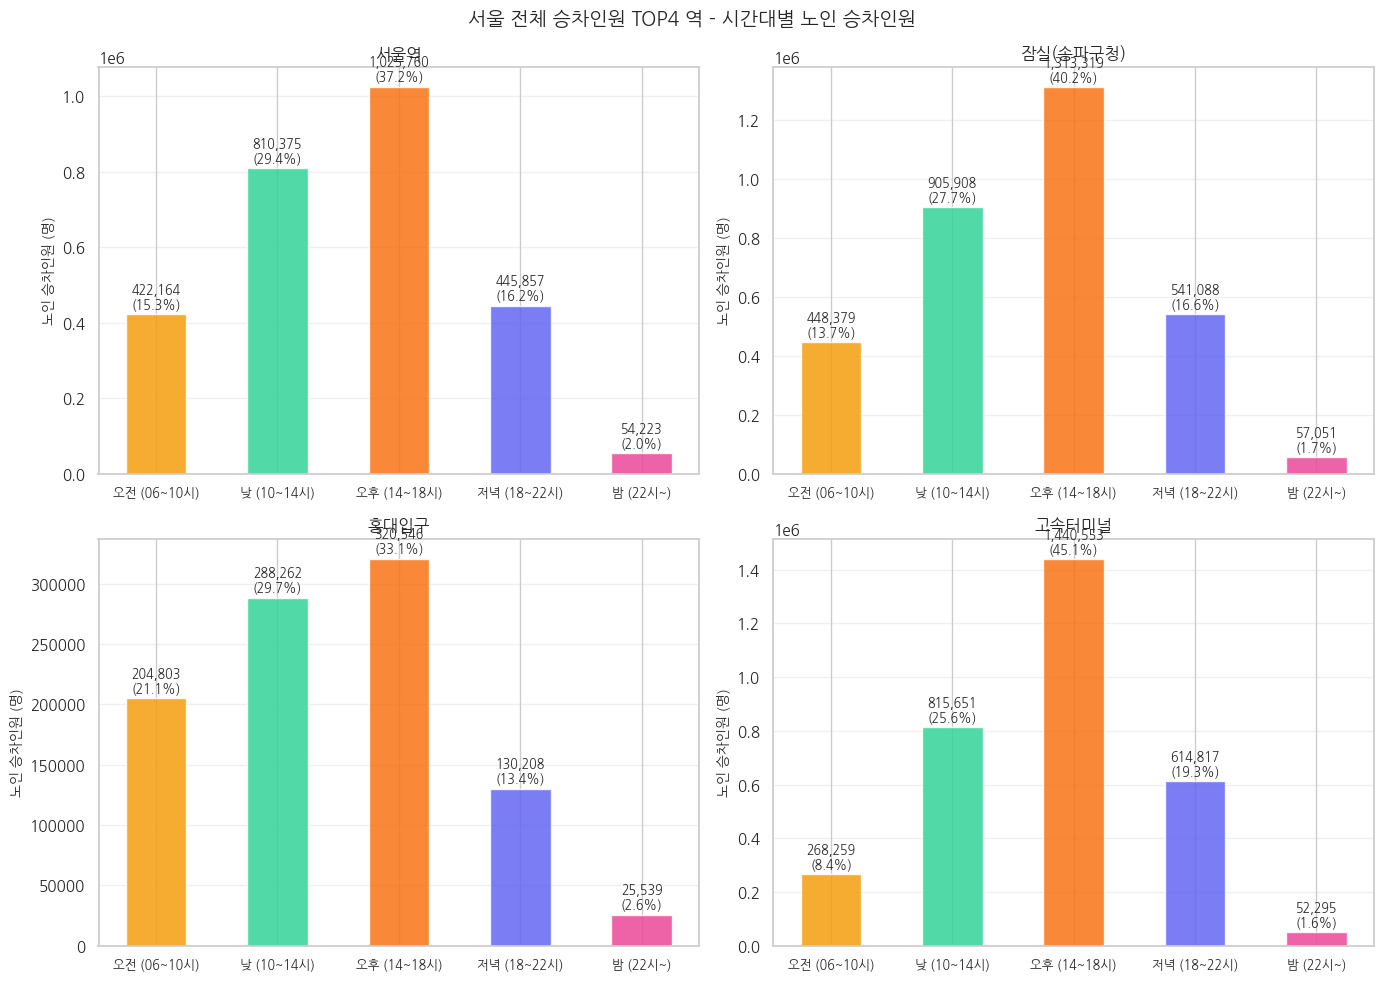

In [46]:
타겟_시간대2_set = 타겟_시간대2.set_index('역명')

for 그룹명, 컬럼들 in 시간대_그룹.items():
    타겟_시간대2_set[그룹명] = 타겟_시간대2_set[컬럼들].sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#F59E0B', '#34D399', '#F97316', '#6366F1', '#EC4899']
역_순서 = ['서울역', '잠실(송파구청)', '홍대입구', '고속터미널']

for i, 역 in enumerate(역_순서):
    ax = axes[i]
    데이터 = 타겟_시간대2_set.loc[역, 그룹_컬럼]
    총합 = 데이터.sum()

    bars = ax.bar(
        [c.replace('\n', ' ') for c in 그룹_컬럼],
        데이터.values,
        color=colors[:len(그룹_컬럼)],
        alpha=0.85,
        width=0.5
    )

    for bar, val in zip(bars, 데이터.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 총합 * 0.005,
            f'{val:,.0f}\n({val/총합*100:.1f}%)',
            ha='center', fontsize=9
        )

    ax.set_title(f'{역}', fontsize=12, fontweight='bold')
    ax.set_ylabel('노인 승차인원 (명)', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('서울 전체 승차인원 TOP4 역 - 시간대별 노인 승차인원', fontsize=14)
plt.tight_layout()
plt.show()

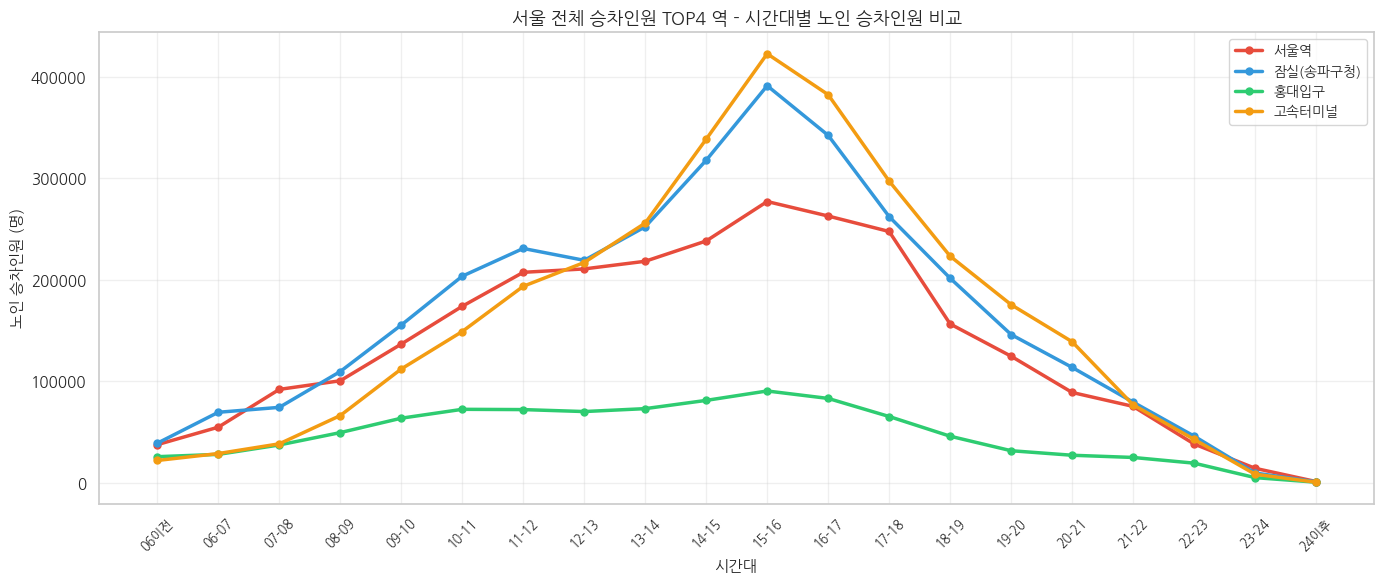

In [47]:
# 꺾은선 비교
fig, ax = plt.subplots(figsize=(14, 6))

line_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

for i, 역 in enumerate(역_순서):
    데이터 = 타겟_시간대2_set.loc[역, 시간대_컬럼]
    ax.plot(range(len(시간대_컬럼)), 데이터.values,
            color=line_colors[i], linewidth=2.5,
            marker='o', markersize=5, label=역)

ax.set_xticks(range(len(시간대_컬럼)))
ax.set_xticklabels([c.replace('시간대', '') for c in 시간대_컬럼], rotation=45, fontsize=9)
ax.set_title('서울 전체 승차인원 TOP4 역 - 시간대별 노인 승차인원 비교', fontsize=13)
ax.set_xlabel('시간대', fontsize=11)
ax.set_ylabel('노인 승차인원 (명)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6-7. 노인 밀집 4역, 대형역 4역 시간대별 노인 승차 평균 패턴 비교
- 노인 밀집역 4개와 서울 주요 대형역 4개의 시간대별 평균 승차 패턴을 비교하여 이용행태의 차이를 확인하였다.

노인 밀집 4역 평균 피크: 10-11시간대
대형역 4역 평균 피크:    15-16시간대


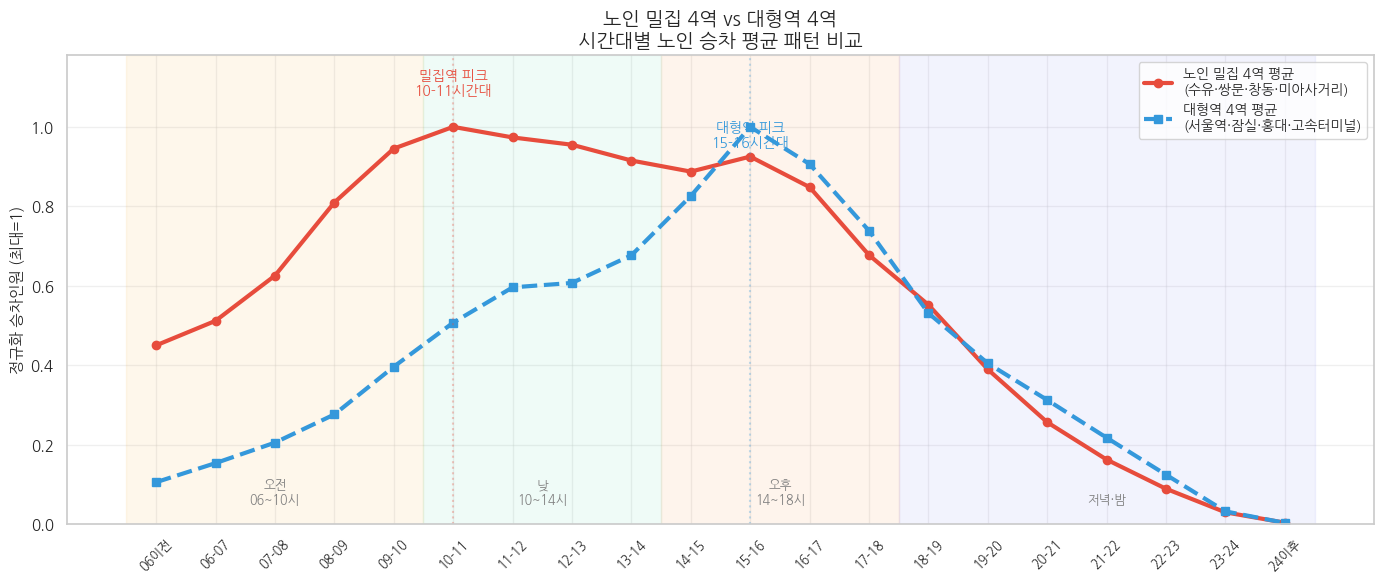

In [48]:
# 노인 밀집 4역 vs 대형역 4역 평균 시간대 패턴 비교
타겟_4역 = ['수유(강북구청)', '쌍문', '창동', '미아사거리']
대형_4역  = ['서울역', '잠실(송파구청)', '홍대입구', '고속터미널']

# 각 그룹 평균
밀집_평균 = (
    역별_시간대[역별_시간대['역명'].isin(타겟_4역)][시간대_컬럼]
    .mean()
)
대형_평균 = (
    역별_시간대[역별_시간대['역명'].isin(대형_4역)][시간대_컬럼]
    .mean()
)

# 정규화
밀집_정규 = 밀집_평균 / 밀집_평균.max()
대형_정규 = 대형_평균 / 대형_평균.max()

# 피크 시간대
밀집_peak_idx = int(밀집_평균.argmax())
대형_peak_idx  = int(대형_평균.argmax())
밀집_peak = 시간대_컬럼[밀집_peak_idx]
대형_peak  = 시간대_컬럼[대형_peak_idx]

print(f'노인 밀집 4역 평균 피크: {밀집_peak}')
print(f'대형역 4역 평균 피크:    {대형_peak}')

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))

밀집_색 = '#E74C3C'
대형_색 = '#3498DB'
x = range(len(시간대_컬럼))

ax.plot(x, 밀집_정규, color=밀집_색, linewidth=3,
        marker='o', markersize=6, label='노인 밀집 4역 평균\n(수유·쌍문·창동·미아사거리)')
ax.plot(x, 대형_정규, color=대형_색, linewidth=3,
        marker='s', markersize=6, linestyle='--', label='대형역 4역 평균\n(서울역·잠실·홍대·고속터미널)')

# 피크 수직선
ax.axvline(밀집_peak_idx, color=밀집_색, alpha=0.3, linestyle=':')
ax.axvline(대형_peak_idx,  color=대형_색, alpha=0.3, linestyle=':')

ax.text(밀집_peak_idx, 1.08,
        f'밀집역 피크\n{밀집_peak}',
        ha='center', fontsize=10, color=밀집_색, fontweight='bold')
ax.text(대형_peak_idx, 0.95,
        f'대형역 피크\n{대형_peak}',
        ha='center', fontsize=10, color=대형_색, fontweight='bold')

# 구간 배경색
ax.axvspan(-0.5, 4.5,  alpha=0.08, color='#F59E0B')
ax.axvspan(4.5,  8.5,  alpha=0.08, color='#34D399')
ax.axvspan(8.5,  12.5, alpha=0.08, color='#F97316')
ax.axvspan(12.5, 19.5, alpha=0.08, color='#6366F1')

# 구간 텍스트
ax.text(2,   0.05, '오전\n06~10시', ha='center', fontsize=9, color='gray')
ax.text(6.5, 0.05, '낮\n10~14시',   ha='center', fontsize=9, color='gray')
ax.text(10.5,0.05, '오후\n14~18시', ha='center', fontsize=9, color='gray')
ax.text(16,  0.05, '저녁·밤',       ha='center', fontsize=9, color='gray')

ax.set_xticks(list(x))
ax.set_xticklabels([c.replace('시간대', '') for c in 시간대_컬럼],
                   rotation=45, fontsize=9)
ax.set_title('노인 밀집 4역 vs 대형역 4역\n시간대별 노인 승차 평균 패턴 비교',
             fontsize=14, fontweight='bold')
ax.set_ylabel('정규화 승차인원 (최대=1)', fontsize=11)
ax.set_ylim(0, 1.18)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6-8. 전체역 평일/주말/공휴일 시각화

In [49]:
# 공휴일 리스트 정의 (2025년)
공휴일_리스트 = [
    '2025-01-01',  # 신정
    '2025-01-28', '2025-01-29', '2025-01-30',  # 설날 연휴
    '2025-03-01',  # 삼일절
    '2025-03-03',  # 삼일절 대체공휴일
    '2025-05-05',  # 어린이날 + 부처님오신날
    '2025-05-06',  # 부처님오신날 대체공휴일
    '2025-06-06',  # 현충일
    '2025-08-15',  # 광복절
    '2025-10-06', '2025-10-07', '2025-10-08',  # 추석 연휴
    '2025-10-09',  # 한글날
    '2025-12-25',  # 성탄절
]

# 날짜구분 컬럼 추가
노인_df['수송일자'] = pd.to_datetime(노인_df['수송일자'])
노인_df['요일'] = 노인_df['수송일자'].dt.dayofweek
노인_df['날짜_str'] = 노인_df['수송일자'].dt.strftime('%Y-%m-%d')

노인_df['날짜구분'] = '평일'
노인_df.loc[노인_df['요일'] >= 5, '날짜구분'] = '주말'
노인_df.loc[노인_df['날짜_str'].isin(공휴일_리스트), '날짜구분'] = '공휴일'

# 확인
print(노인_df['날짜구분'].value_counts())
print('\n공휴일 날짜 샘플:')
print(노인_df[노인_df['날짜구분'] == '공휴일']['날짜_str'].unique())

날짜구분
평일     134928
주말      56262
공휴일      8194
Name: count, dtype: int64

공휴일 날짜 샘플:
['2025-01-01' '2025-01-28' '2025-01-29' '2025-01-30' '2025-03-01'
 '2025-03-03' '2025-05-05' '2025-05-06' '2025-06-06' '2025-08-15'
 '2025-10-06' '2025-10-07' '2025-10-08' '2025-10-09' '2025-12-25']


In [50]:
# 평일/주말/공휴일 시간대별 평균
노인_승차_구분 = 노인_df[노인_df['승하차구분'] == '승차'].copy()

평일_시간대   = 노인_승차_구분[노인_승차_구분['날짜구분'] == '평일'][시간대_컬럼].mean()
주말_시간대   = 노인_승차_구분[노인_승차_구분['날짜구분'] == '주말'][시간대_컬럼].mean()
공휴일_시간대 = 노인_승차_구분[노인_승차_구분['날짜구분'] == '공휴일'][시간대_컬럼].mean()

# 정규화
평일_정규   = 평일_시간대   / 평일_시간대.max()
주말_정규   = 주말_시간대   / 주말_시간대.max()
공휴일_정규 = 공휴일_시간대 / 공휴일_시간대.max()

# 일평균 절대값 비교
평일_일평균   = 노인_승차_구분[노인_승차_구분['날짜구분'] == '평일'].groupby('수송일자')[시간대_컬럼].sum().sum(axis=1).mean()
주말_일평균   = 노인_승차_구분[노인_승차_구분['날짜구분'] == '주말'].groupby('수송일자')[시간대_컬럼].sum().sum(axis=1).mean()
공휴일_일평균 = 노인_승차_구분[노인_승차_구분['날짜구분'] == '공휴일'].groupby('수송일자')[시간대_컬럼].sum().sum(axis=1).mean()

print(f'평일 일평균:   {평일_일평균:,.0f}명')
print(f'주말 일평균:   {주말_일평균:,.0f}명')
print(f'공휴일 일평균: {공휴일_일평균:,.0f}명')

평일 일평균:   720,445명
주말 일평균:   522,626명
공휴일 일평균: 400,397명


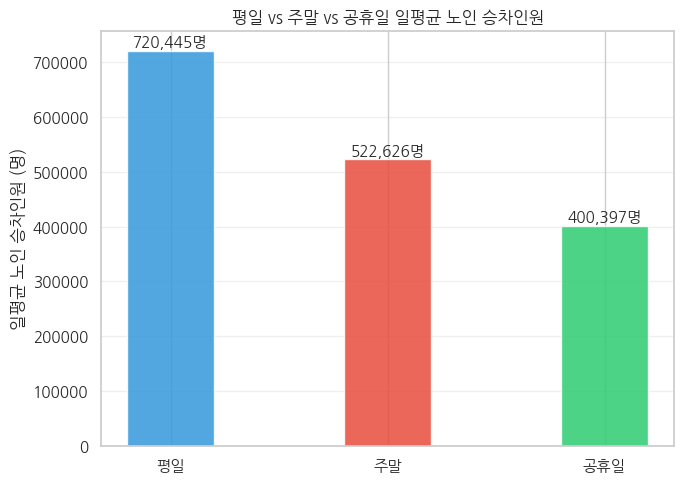

In [51]:
plt.figure(figsize=(7, 5))

일평균_값 = [평일_일평균, 주말_일평균, 공휴일_일평균]
일평균_라벨 = ['평일', '주말', '공휴일']

bar_colors = ['#3498DB', '#E74C3C', '#2ECC71']

bars = plt.bar(
    일평균_라벨,
    일평균_값,
    color=bar_colors,
    alpha=0.85,
    width=0.4
)

for bar, val in zip(bars, 일평균_값):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(일평균_값) * 0.01,
        f'{val:,.0f}명',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('평일 vs 주말 vs 공휴일 일평균 노인 승차인원')
plt.ylabel('일평균 노인 승차인원 (명)')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 6-9. 무임승차 집중 역 평일/주말/공휴일

In [52]:
### 6-9. 서울 무임승차 집중역의 평일·주말·공휴일 노인 승차 비교

# 서울 무임승차 집중역 목록
집중역_목록 = top20_서울_5['지하철역'].tolist()

print('서울 무임승차 집중역 목록')
print(집중역_목록)
print(f'집중역 개수: {len(집중역_목록)}개')

서울 무임승차 집중역 목록
['제기동', '도봉', '방학', '동묘앞', '청량리(서울시립대입구)', '종로5가', '망우', '도봉산', '길동', '불광', '월계', '신설동', '독립문', '수락산', '창동', '굽은다리(강동구민회관앞)', '가락시장', '명일', '방화', '동대문']
집중역 개수: 20개


In [53]:
# 노인 승차 데이터만 추출
노인_승차_집중역 = 노인_df[
    (노인_df['승하차구분'] == '승차') &
    (노인_df['역명'].isin(집중역_목록))
].copy()

# 날짜 타입 변환
노인_승차_집중역['수송일자'] = pd.to_datetime(노인_승차_집중역['수송일자'])
노인_승차_집중역['요일'] = 노인_승차_집중역['수송일자'].dt.dayofweek
노인_승차_집중역['날짜_str'] = 노인_승차_집중역['수송일자'].dt.strftime('%Y-%m-%d')

# 평일/주말/공휴일 구분
노인_승차_집중역['날짜구분'] = '평일'
노인_승차_집중역.loc[노인_승차_집중역['요일'] >= 5, '날짜구분'] = '주말'
노인_승차_집중역.loc[
    노인_승차_집중역['날짜_str'].isin(공휴일_리스트),
    '날짜구분'
] = '공휴일'

# 시간대별 승차인원 합산
노인_승차_집중역['일별합계'] = 노인_승차_집중역[시간대_컬럼].sum(axis=1)

print('매칭된 집중역 개수:', 노인_승차_집중역['역명'].nunique())
print('매칭 안 된 역:', set(집중역_목록) - set(노인_승차_집중역['역명'].unique()))

display(노인_승차_집중역[['수송일자', '역명', '날짜구분', '일별합계']].head())

매칭된 집중역 개수: 16
매칭 안 된 역: {'방학', '망우', '월계', '도봉'}


,수송일자,역명,날짜구분,일별합계
8,2025-01-01,종로5가,공휴일,2970
10,2025-01-01,동대문,공휴일,1888
12,2025-01-01,신설동,공휴일,1870
14,2025-01-01,제기동,공휴일,4500
16,2025-01-01,청량리(서울시립대입구),공휴일,4991


In [54]:
# 날짜구분별 일평균 계산
# 먼저 날짜별로 집중역 전체 승차인원을 합산한 뒤 평균을 계산

집중역_일별 = (
    노인_승차_집중역
    .groupby(['수송일자', '날짜구분'])['일별합계']
    .sum()
    .reset_index()
)

집중역_날짜구분_평균 = (
    집중역_일별
    .groupby('날짜구분')['일별합계']
    .mean()
    .reindex(['평일', '주말', '공휴일'])
    .reset_index()
    .rename(columns={'일별합계': '일평균_노인승차'})
)

display(집중역_날짜구분_평균)

,날짜구분,일평균_노인승차
0,평일,77475.364372
1,주말,66992.475728
2,공휴일,50357.933333


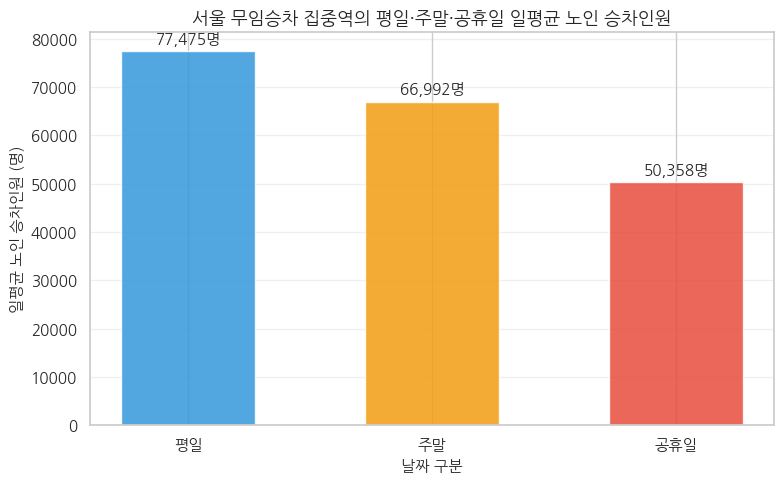

In [55]:
# 막대그래프 시각화

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#3498DB', '#F39C12', '#E74C3C']

bars = ax.bar(
    집중역_날짜구분_평균['날짜구분'],
    집중역_날짜구분_평균['일평균_노인승차'],
    color=colors,
    alpha=0.85,
    width=0.55
)

for bar, val in zip(bars, 집중역_날짜구분_평균['일평균_노인승차']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 집중역_날짜구분_평균['일평균_노인승차'].max() * 0.02,
        f'{val:,.0f}명',
        ha='center',
        fontsize=11
    )

ax.set_title('서울 무임승차 집중역의 평일·주말·공휴일 일평균 노인 승차인원', fontsize=13)
ax.set_xlabel('날짜 구분', fontsize=11)
ax.set_ylabel('일평균 노인 승차인원 (명)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 가설 A-2 결과 해석

- 시간대별 분석 결과, 노인 밀집 지역의 역은 오전 시간대 이용이 집중된 반면 도심 대형 역은 오후 시간대 이용 비중이 높게 나타났다.
- 무임승차 집중 상위 20개 역의 평일의 일평균 노인 승차 인원은 주말보다 높게 나타났으며, 이는 병원·경로당·은행 등 생활 밀착형 시설 방문 수요의 영향을 받은 것으로 해석된다.

## 가설 B. 유・무임 승객의 이동 패턴 차이

### 7-1. 무임 이용객의 승·하차 비중 차이 비교

In [56]:
# 파일 순서 저장
target_stations = top20_위치['역이름'].tolist()

# 집계
result_3 = (
    subway_df[subway_df['지하철역'].isin(target_stations)]
    .groupby(['지하철역', '시도', '자치구'], dropna=False)
    .agg(
        승차인원합계=('총승차인원', 'sum'),
        하차인원합계=('총하차인원', 'sum'),
        무임승차인원=('무임승차인원', 'sum'),
        무임하차인원=('무임하차인원', 'sum'),
        유임승차인원=('유임승차인원', 'sum'),
        유임하차인원=('유임하차인원', 'sum')
    )
    .reset_index()
)

# 차이 계산
result_3['무임승하차차이'] = (
    result_3['무임승차인원'] - result_3['무임하차인원']
)

result_3['유임승하차차이'] = (
    result_3['유임승차인원'] - result_3['유임하차인원']
)

# CSV 순서대로 정렬
result_3['정렬순서'] = pd.Categorical(
    result_3['지하철역'],
    categories=target_stations,
    ordered=True
)

result_3 = (
    result_3
    .sort_values('정렬순서')
    .drop(columns='정렬순서')
    .reset_index(drop=True)
)

display(result_3)

,지하철역,시도,자치구,승차인원합계,하차인원합계,무임승차인원,무임하차인원,유임승차인원,유임하차인원,무임승하차차이,유임승하차차이
0,제기동,서울특별시,동대문구,5874385,6026590,3159431,3418061,2714954,2608529,-258630,106425
1,도봉,서울특별시,도봉구,2080366,1986405,906364,893107,1174002,1093298,13257,80704
2,방학,서울특별시,도봉구,3575857,3476215,1432404,1395109,2143453,2081106,37295,62347
3,동묘앞,서울특별시,종로구,7206213,7320106,2838819,2798193,4367394,4521913,40626,-154519
4,청량리(서울시립대입구),서울특별시,동대문구,15050598,15124840,5473631,5592158,9576967,9532682,-118527,44285
5,종로5가,서울특별시,종로구,8542065,8352150,2947067,2865732,5594998,5486418,81335,108580
6,망우,서울특별시,중랑구,2762212,2680863,941323,952400,1820889,1728463,-11077,92426
7,도봉산,서울특별시,도봉구,6033557,5626870,2043371,2013903,3990186,3612967,29468,377219
8,길동,서울특별시,강동구,3202188,3256955,1073149,1097131,2129039,2159824,-23982,-30785
9,불광,서울특별시,은평구,7668121,7935390,2454281,2536901,5213840,5398489,-82620,-184649


### 7-2. 산점도

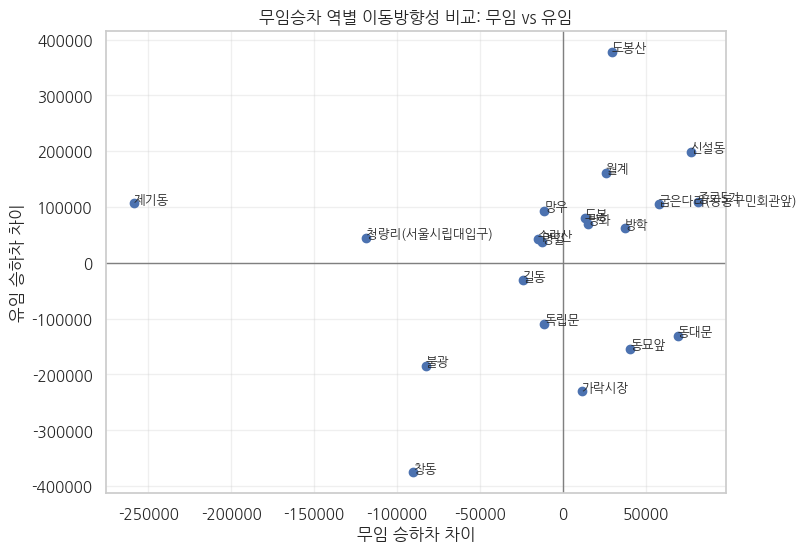

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    result_3['무임승하차차이'],
    result_3['유임승하차차이']
)

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

for i in range(len(result_3)):
    plt.text(
        result_3['무임승하차차이'].iloc[i],
        result_3['유임승하차차이'].iloc[i],
        result_3['지하철역'].iloc[i],
        fontsize=9
    )

plt.xlabel('무임 승하차 차이')
plt.ylabel('유임 승하차 차이')
plt.title('무임승차 역별 이동방향성 비교: 무임 vs 유임')
plt.grid(alpha=0.3)
plt.show()

In [58]:
# 2사분면, 4사분면만 추출
opposite_df = result_3[
    result_3['무임승하차차이'] * result_3['유임승하차차이'] < 0
].copy()

/tmp/ipykernel_2618/2299284934.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


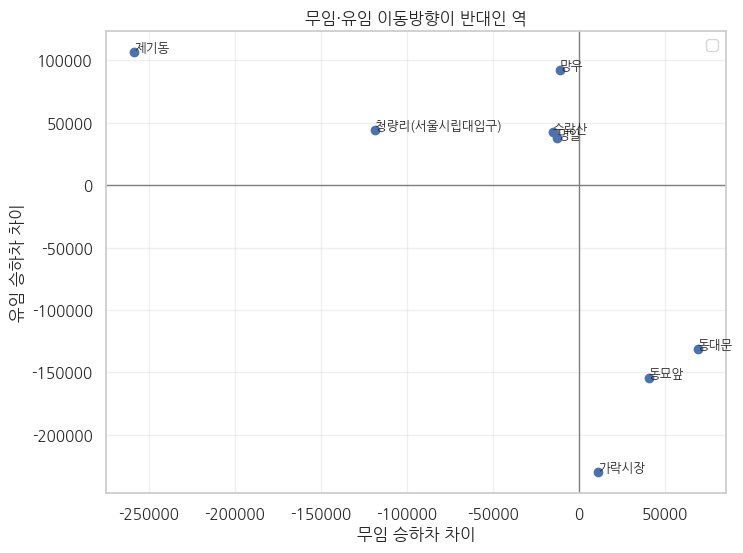

In [59]:
plt.figure(figsize=(8, 6))

plt.scatter(
    opposite_df['무임승하차차이'],
    opposite_df['유임승하차차이']
)

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)


for i in range(len(opposite_df)):
    plt.text(
        opposite_df['무임승하차차이'].iloc[i],
        opposite_df['유임승하차차이'].iloc[i],
        opposite_df['지하철역'].iloc[i],
        fontsize=9
    )

plt.xlabel('무임 승하차 차이')
plt.ylabel('유임 승하차 차이')
plt.title('무임·유임 이동방향이 반대인 역')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

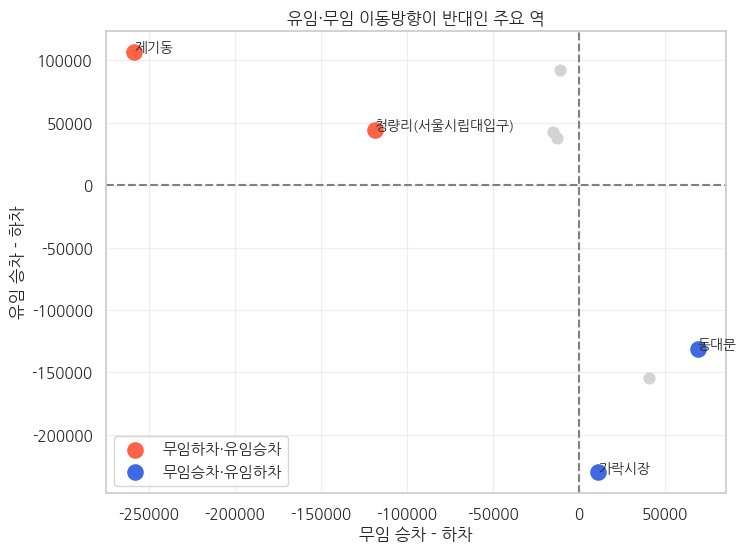

In [60]:
# 차이 크기 계산
opposite_df['차이강도'] = (
    opposite_df['무임승하차차이'].abs()
    + opposite_df['유임승하차차이'].abs()
)

# 2사분면
quad2_top2 = (
    opposite_df[
        (opposite_df['무임승하차차이'] < 0) &
        (opposite_df['유임승하차차이'] > 0)
    ]
    .sort_values('차이강도', ascending=False)
    .head(2)
)

# 4사분면
quad4_top2 = (
    opposite_df[
        (opposite_df['무임승하차차이'] > 0) &
        (opposite_df['유임승하차차이'] < 0)
    ]
    .sort_values('차이강도', ascending=False)
    .head(2)
)

# 시각화
plt.figure(figsize=(8, 6))

# 전체 역
plt.scatter(
    opposite_df['무임승하차차이'],
    opposite_df['유임승하차차이'],
    color='lightgray',
    s=60
)

# 2사분면 TOP2
plt.scatter(
    quad2_top2['무임승하차차이'],
    quad2_top2['유임승하차차이'],
    color='tomato',
    s=120,
    label='무임하차·유임승차'
)

# 4사분면 TOP2
plt.scatter(
    quad4_top2['무임승하차차이'],
    quad4_top2['유임승하차차이'],
    color='royalblue',
    s=120,
    label='무임승차·유임하차'
)

# 역 이름 표시
for _, row in pd.concat([quad2_top2, quad4_top2]).iterrows():
    plt.text(
        row['무임승하차차이'],
        row['유임승하차차이'],
        row['지하철역'],
        fontsize=10
    )

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel('무임 승차 - 하차')
plt.ylabel('유임 승차 - 하차')
plt.title('유임·무임 이동방향이 반대인 주요 역')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 7-3. 막대그래프 시각화

In [61]:
# 절대값 기준 격차 계산
opposite_df['승하차_격차'] = (
    opposite_df['무임승하차차이'].abs()
    - opposite_df['유임승하차차이'].abs()
).abs()

# 내림차순 정렬
opposite_df = (
    opposite_df
    .sort_values('승하차_격차', ascending=False)
    .reset_index(drop=True)
)

display(
    opposite_df[
        ['지하철역', '무임승하차차이', '유임승하차차이', '승하차_격차']
    ]
)

,지하철역,무임승하차차이,유임승하차차이,승하차_격차
0,가락시장,11341,-230040,218699
1,제기동,-258630,106425,152205
2,동묘앞,40626,-154519,113893
3,망우,-11077,92426,81349
4,청량리(서울시립대입구),-118527,44285,74242
5,동대문,69204,-131044,61840
6,수락산,-15182,42146,26964
7,명일,-12599,37772,25173


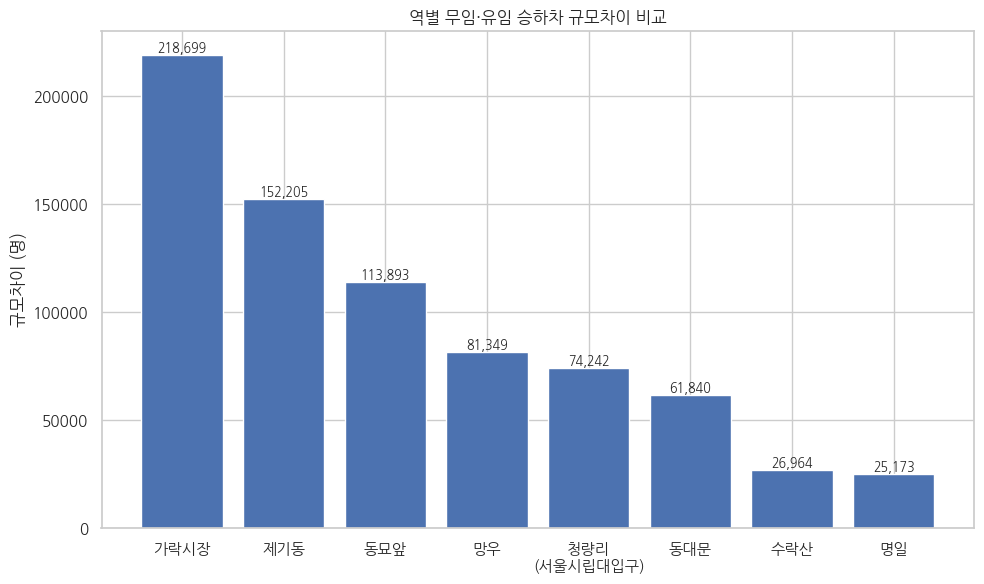

In [62]:
# 그래프용 역 이름
station_names = opposite_df['지하철역'].replace(
    {'청량리(서울시립대입구)': '청량리\n(서울시립대입구)'}
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    station_names,
    opposite_df['승하차_격차']
)

plt.title('역별 무임·유임 승하차 규모차이 비교')
plt.ylabel('규모차이 (명)')

plt.xticks(rotation=0)

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f'{h:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 가설 B 결과 해석

- 일부 역에서는 무임 승객과 유임 승객의 승하차 방향이 반대로 나타나 동일한 역을 서로 다른 목적으로 이용하고 있음을 확인하였다.
- 제기동·망우는 무임 목적지형, 가락시장·동묘앞은 무임 출발지형으로 구분되었으며, 이는 무임 승객과 유임 승객의 이동 행태가 서로 다를 수 있음을 시사한다.

# 결론 및 분석 한계

## 결론
- 무임승차 집중 현상은 고령인구 비율, 노인여가시설 분포, 이용 패턴 등 여러 요인이 복합적으로 작용한 결과로 나타났다.
- 무임승차 집중 역은 외곽 주거지형과 도심 목적지형으로 구분되었으며, 노인 이용자의 이동 특성은 역의 지역적 성격에 따라 다르게 나타났다.
- 따라서 무임승차 정책 및 운영 전략은 전체 노선에 일률적으로 적용하기보다 역 유형과 이용 특성을 고려한 접근이 필요할 것으로 판단된다.

## 분석 한계
- 자치구 단위 고령인구 비율을 역 단위 분석에 적용하여 공간적 정밀도에 한계가 있다.
- 데이터셋 간 분석 기간이 완전히 일치하지 않으며, 노인복지시설은 경로당만을 대상으로 분석하였다.
- 실제 이동 경로를 확인할 수 없어 이동 목적과 동선은 승하차 패턴을 통해 간접적으로 추정하였다.
- 서울시 제공 데이터에 기반하여 분석 범위를 서울 소재 역으로 한정하였다.

# [부록]

## 추가 EDA

### 부록 3-1. 호선명 통합
- 경부선, 경인선, 장항선 → 1호선
- 경의선, 중앙선 → 경의중앙선
- 경원선은 역별로 1호선 / 경의중앙선으로 분리

In [63]:
# 기본 통합 규칙
line_mapping = {
    '경부선': '1호선',
    '경의선': '경의중앙선',
    '경인선': '1호선',
    '경춘선': '경춘선',
    '과천선': '4호선',
    '분당선': '수인분당선',
    '서해선': '서해선',
    '수인선': '수인분당선',
    '신림선': '신림선',
    '안산선': '4호선',
    '우이신설선': '우이신설선',
    '일산선': '3호선',
    '장항선': '1호선',
    '중앙선': '경의중앙선',
    '9호선2~3단계': '9호선'
}

# 경원선 예외 처리
경의중앙선_역 = [
    '이촌(국립중앙박물관)', '서빙고', '한남', '옥수',
    '응봉', '왕십리(성동구청)', '청량리(서울시립대입구)'
]
line1_역 = [
    '외대앞', '신이문', '석계', '광운대', '월계', '녹천',
    '창동', '방학', '도봉', '도봉산', '망월사', '회룡',
    '의정부', '가능', '녹양', '양주', '덕계', '덕정',
    '지행', '동두천중앙', '보산', '동두천', '소요산',
    '청산', '전곡', '연천'
]

subway_df['통합호선'] = subway_df['호선명'].replace(line_mapping)

subway_df.loc[
    (subway_df['호선명'] == '경원선') &
    (subway_df['지하철역'].isin(경의중앙선_역)),
    '통합호선'
] = '경의중앙선'

subway_df.loc[
    (subway_df['호선명'] == '경원선') &
    (subway_df['지하철역'].isin(line1_역)),
    '통합호선'
] = '1호선'

print('통합 후 호선명:', sorted(subway_df['통합호선'].unique()))

통합 후 호선명: ['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선', '9호선', '경강선', '경의중앙선', '경춘선', '공항철도 1호선', '서해선', '수인분당선', '신림선', '우이신설선']


### 부록 3-2. 호선별 평균 무임승차비율 비교

        통합호선    무임승차비율
16     우이신설선  0.388978
11       경춘선  0.360716
10     경의중앙선  0.298691
15       신림선  0.277687
0        1호선  0.257213
7        8호선  0.231340
14     수인분당선  0.217059
4        5호선  0.215389
9        경강선  0.212868
2        3호선  0.211492
6        7호선  0.202378
3        4호선  0.200774
13       서해선  0.191530
5        6호선  0.190031
8        9호선  0.177340
1        2호선  0.153901
12  공항철도 1호선  0.103199


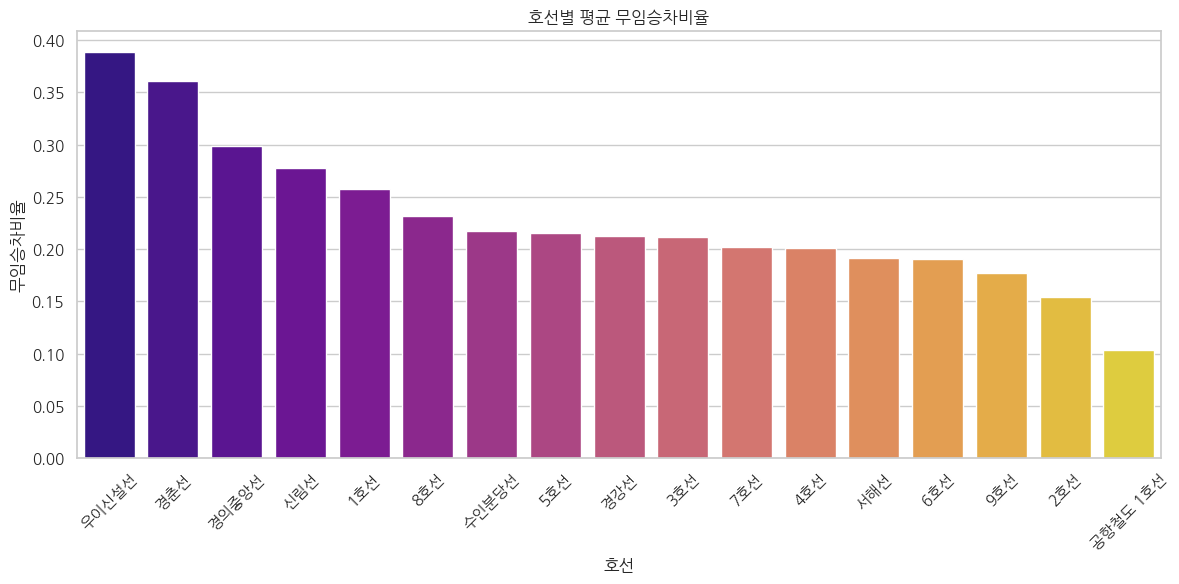

In [64]:
호선별 = (
    subway_df.groupby('통합호선')['무임승차비율']
    .mean()
    .reset_index()
    .sort_values('무임승차비율', ascending=False)
)

print(호선별)

plt.figure(figsize=(12, 6))
sns.barplot(data=호선별, x='통합호선', y='무임승차비율',
            hue='통합호선', palette='plasma', legend=False)
plt.title('호선별 평균 무임승차비율')
plt.xlabel('호선')
plt.ylabel('무임승차비율')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 부록 3-3. 환승역 vs 비환승역 무임승차비율 비교

     환승역    무임승차비율
0  False  0.239644
1   True  0.187610


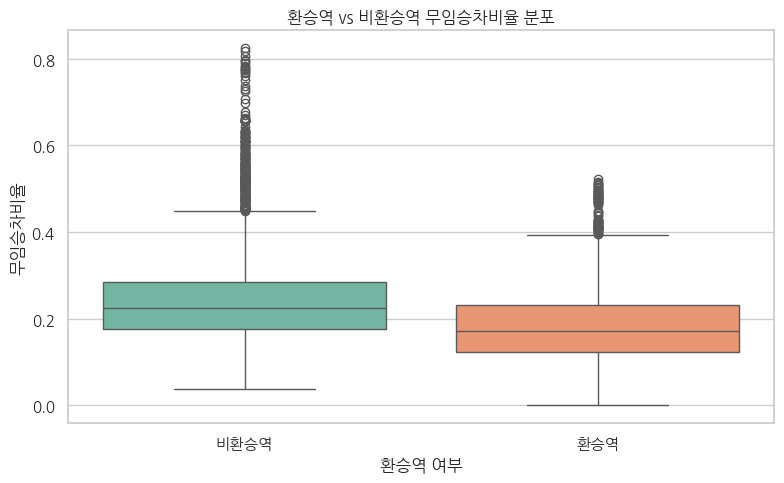

In [65]:
환승별 = (
    subway_df.groupby('환승역')['무임승차비율']
    .mean()
    .reset_index()
    .sort_values('무임승차비율', ascending=False)
)
print(환승별)

plt.figure(figsize=(8, 5))
sns.boxplot(data=subway_df, x='환승역', y='무임승차비율',
            hue='환승역', palette='Set2', legend=False)
plt.title('환승역 vs 비환승역 무임승차비율 분포')
plt.xlabel('환승역 여부')
plt.ylabel('무임승차비율')
plt.xticks([0, 1], ['비환승역', '환승역'])
plt.tight_layout()
plt.show()

### 부록 3-4. 전체 역의 고령인구비율과 무임승차비율 관계 분석
- 고령인구비율이 높은 지역일수록 무임승차비율도 함께 높게 나타나는지 확인하고자 하였다.
- 두 변수의 관계를 시각적으로 살펴봄으로써, 지역의 인구구조와 무임승차 이용 간 관련성을 탐색한다.

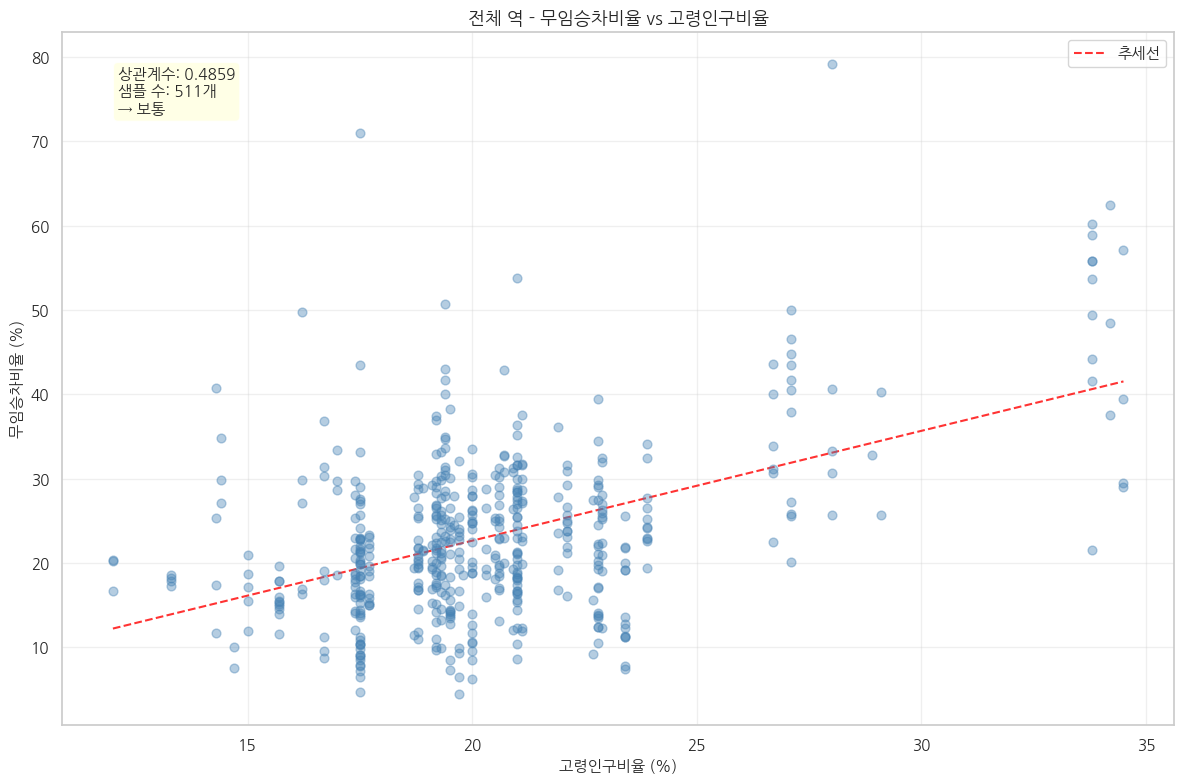

상관계수: 0.4859


In [66]:
유효_b = 전체역_고령.dropna(
    subset=['고령인구비율', '무임승차비율']
)

z = np.polyfit(
    유효_b['고령인구비율'],
    유효_b['무임승차비율'],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    유효_b['고령인구비율'].min(),
    유효_b['고령인구비율'].max(),
    100
)

corr_b = 유효_b['고령인구비율'].corr(
    유효_b['무임승차비율']
)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    유효_b['고령인구비율'],
    유효_b['무임승차비율'],
    s=40,
    color='steelblue',
    alpha=0.4,
    zorder=5
)

ax.plot(
    x_line,
    p(x_line),
    color='red',
    linestyle='--',
    alpha=0.8,
    label='추세선'
)

ax.text(
    0.05,
    0.95,
    f'상관계수: {corr_b:.4f}\n샘플 수: {len(유효_b)}개\n→ {"약함" if abs(corr_b) < 0.3 else "보통" if abs(corr_b) < 0.7 else "강함"}',
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax.set_title('전체 역 - 무임승차비율 vs 고령인구비율', fontsize=13)
ax.set_xlabel('고령인구비율 (%)', fontsize=11)
ax.set_ylabel('무임승차비율 (%)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'상관계수: {corr_b:.4f}')

In [67]:
print('원본 행 수:', len(subway_df))
print('고유 역 수:', subway_df['지하철역'].nunique())

원본 행 수: 7416
고유 역 수: 528


## 가설 A. 추가 EDA - 무임승차비율을 중앙값으로 둘 때

### 부록 4-1. 무임승차비율 중앙값 설정

In [68]:
# 역별 집계
역별_집계_비율 = (
    subway_df.groupby(['지하철역', '환승역', '시도', '자치구'], dropna=False)
    .agg(
        승차인원합계=('총승차인원', 'sum'),
        무임승차인원=('무임승차인원', 'sum'),
        유임승차인원=('유임승차인원', 'sum'),
        무임하차인원=('무임하차인원', 'sum'),
        유임하차인원=('유임하차인원', 'sum')
    )
    .reset_index()
)

# 무임승차비율 계산
역별_집계_비율['무임승차비율'] = (
    역별_집계_비율['무임승차인원']
    / 역별_집계_비율['승차인원합계']
) * 100

# 중앙값 계산
중앙값_비율 = 역별_집계_비율['무임승차비율'].median()
print(f'무임승차율 중앙값: {중앙값_비율:.4f}%')

# TOP20 추출
top20_비율 = (
    역별_집계_비율[
        역별_집계_비율['무임승차비율'] >= 중앙값_비율
    ]
    .sort_values('무임승차인원', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# 고령인구비율 merge
top20_비율 = top20_비율.merge(
    고령_df[['시도', '자치구', '고령인구비율']],
    on=['시도', '자치구'],
    how='left'
)

# 승하차 차이
top20_비율['무임_차이'] = (
    top20_비율['무임승차인원']
    - top20_비율['무임하차인원']
)

top20_비율['유임_차이'] = (
    top20_비율['유임승차인원']
    - top20_비율['유임하차인원']
)

display(
    top20_비율[
        [
            '지하철역',
            '시도',
            '자치구',
            '승차인원합계',
            '무임승차인원',
            '무임승차비율',
            '고령인구비율',
            '무임_차이',
            '유임_차이',
            '환승역'
        ]
    ]
)

무임승차율 중앙값: 21.7622%


,지하철역,시도,자치구,승차인원합계,무임승차인원,무임승차비율,고령인구비율,무임_차이,유임_차이,환승역
0,종로3가,서울특별시,종로구,19056886,5521648,28.974555,22.8,164965,119481,True
1,청량리(서울시립대입구),서울특별시,동대문구,15050598,5473631,36.368196,21.0,-118527,44285,True
2,영등포,서울특별시,영등포구,15458874,3870806,25.039379,19.5,547,-115161,False
3,천호(풍납토성),서울특별시,강동구,13745010,3531790,25.695070,20.0,13662,-613965,True
4,동대문,서울특별시,종로구,11422533,3411905,29.869951,22.8,69204,-131044,True
5,연신내,서울특별시,은평구,13232704,3361496,25.402941,22.9,121824,542093,True
6,노원,서울특별시,노원구,14655015,3208204,21.891509,22.1,10883,-1252345,True
7,제기동,서울특별시,동대문구,5874385,3159431,53.783179,21.0,-258630,106425,False
8,부천,경기도,부천시,11339613,3098325,27.323022,21.1,-45365,35825,False
9,모란,경기도,성남시,9124453,3029899,33.206363,19.3,-58666,212026,True


### 부록 4-2. 시각화

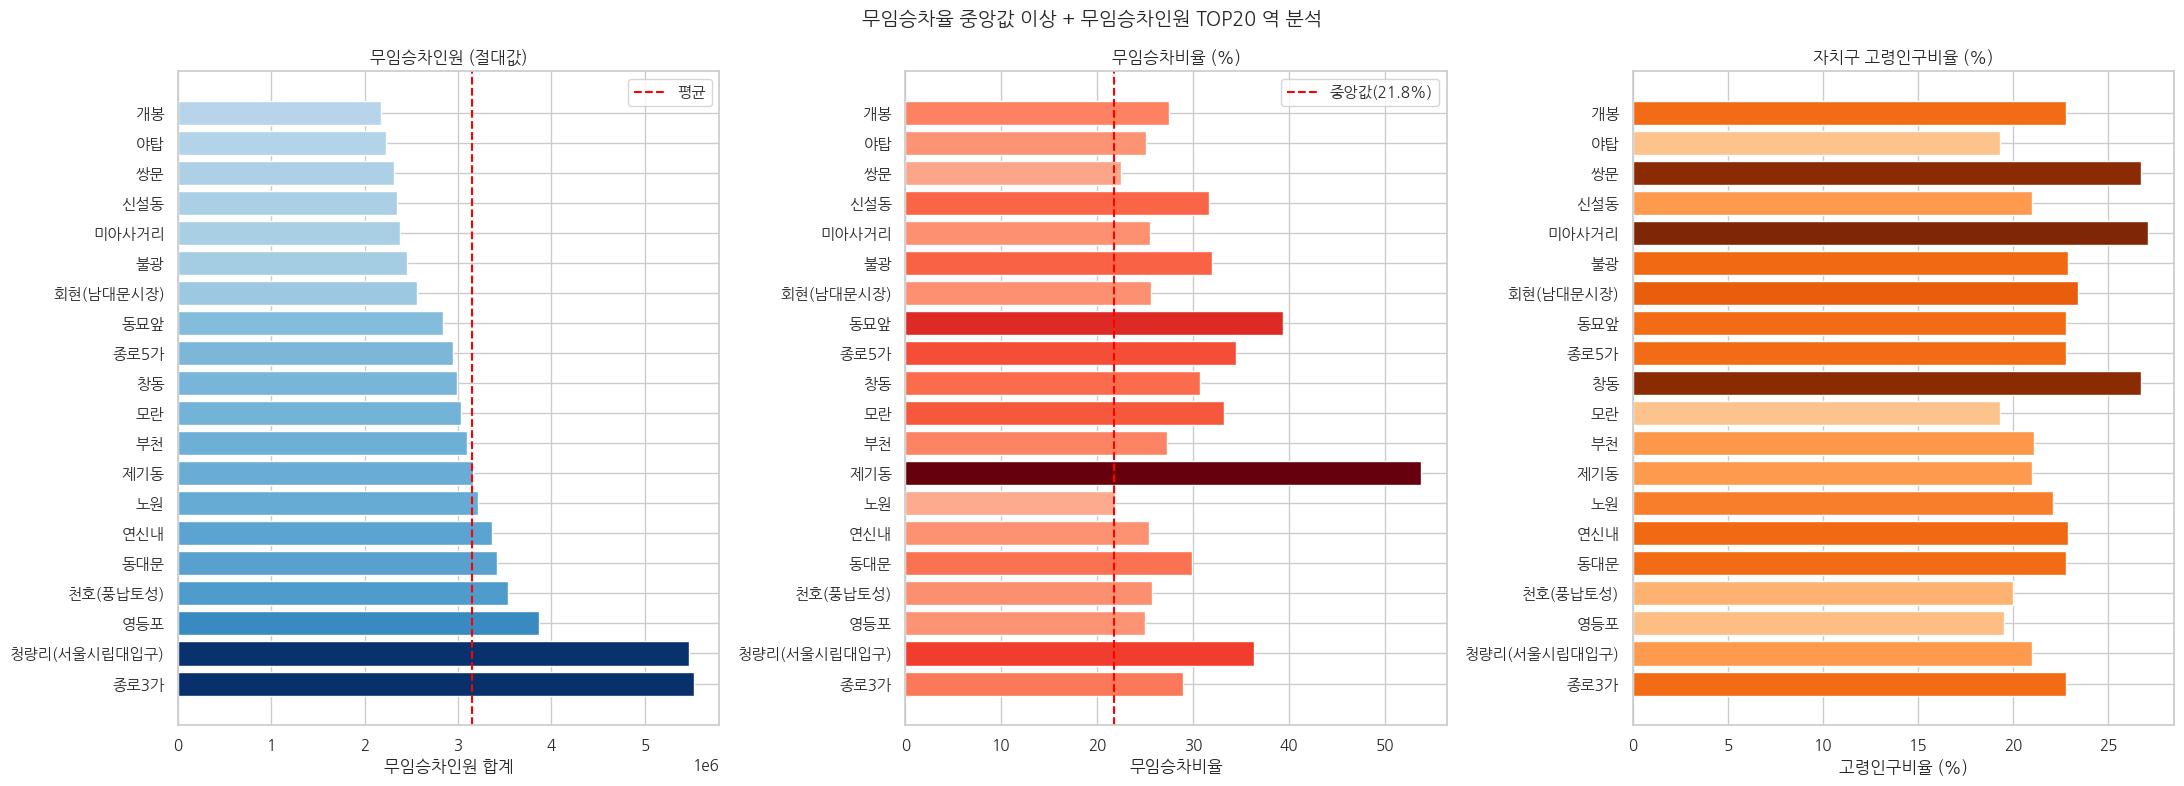

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

def make_colors(series, cmap):
    norm = (series - series.min()) / (series.max() - series.min())
    return [cmap(0.3 + 0.7 * v) for v in norm]

무임인원_colors = make_colors(top20_비율['무임승차인원'], plt.cm.Blues)
무임비율_colors = make_colors(top20_비율['무임승차비율'], plt.cm.Reds)
고령_colors = make_colors(top20_비율['고령인구비율'].fillna(0), plt.cm.Oranges)

axes[0].barh(
    top20_비율['지하철역'],
    top20_비율['무임승차인원'],
    color=무임인원_colors
)
axes[0].set_title('무임승차인원 (절대값)')
axes[0].set_xlabel('무임승차인원 합계')
axes[0].axvline(
    top20_비율['무임승차인원'].mean(),
    color='red',
    linestyle='--',
    label='평균'
)
axes[0].legend()

axes[1].barh(
    top20_비율['지하철역'],
    top20_비율['무임승차비율'],
    color=무임비율_colors
)
axes[1].set_title('무임승차비율 (%)')
axes[1].set_xlabel('무임승차비율')
axes[1].axvline(
    중앙값_비율,
    color='red',
    linestyle='--',
    label=f'중앙값({중앙값_비율:.1f}%)'
)
axes[1].legend()

axes[2].barh(
    top20_비율['지하철역'],
    top20_비율['고령인구비율'],
    color=고령_colors
)
axes[2].set_title('자치구 고령인구비율 (%)')
axes[2].set_xlabel('고령인구비율 (%)')

plt.suptitle('무임승차율 중앙값 이상 + 무임승차인원 TOP20 역 분석', fontsize=14)
plt.tight_layout()
plt.show()

### 부록 4-3. 지도 시각화

In [70]:
import folium
import requests
import geopandas as gpd
import pandas as pd

# GeoJSON
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
geo_data = requests.get(geo_url).json()

# 서울 자치구 고령인구비율
서울_고령 = 고령_df[
    (고령_df['시도'] == '서울특별시') &
    (고령_df['자치구'] != '소계')
].reset_index(drop=True)

# 배경지도 없이 지도 생성
map1 = folium.Map(
    location=[37.5665, 126.9780],
    zoom_start=11,
    tiles=None
)

# 서울 자치구 색상
folium.Choropleth(
    geo_data=geo_data,
    data=서울_고령,
    columns=['자치구', '고령인구비율'],
    key_on='feature.properties.name',
    fill_color='Blues',
    fill_opacity=0.85,
    line_opacity=0.8,
    line_color='white',
    legend_name='고령인구비율 (%)',
    nan_fill_color='lightgray'
).add_to(map1)

# ==========================
# 자치구 중심점 자동 계산
# ==========================
seoul_geo = gpd.GeoDataFrame.from_features(geo_data['features'])
seoul_geo = seoul_geo.set_crs(epsg=4326)

seoul_geo_5179 = seoul_geo.to_crs(epsg=5179)
seoul_geo_5179['중심점'] = seoul_geo_5179.geometry.centroid

centroid_gdf = gpd.GeoDataFrame(
    seoul_geo_5179[['name']],
    geometry=seoul_geo_5179['중심점'],
    crs=seoul_geo_5179.crs
).to_crs(epsg=4326)

구_좌표 = {
    row['name']: [row.geometry.y, row.geometry.x]
    for _, row in centroid_gdf.iterrows()
}

# TOP20 역 위치
역_위치 = {
    '종로3가': [37.5718, 126.9918],
    '청량리(서울시립대입구)': [37.580178, 127.046835],
    '영등포': [37.5155, 126.9072],
    '천호(풍납토성)': [37.5387, 127.1237],
    '동대문': [37.571420, 127.009745],
    '연신내': [37.6191, 126.9196],
    '노원': [37.6556, 127.0637],
    '제기동': [37.578113, 127.034813],
    '부천': [37.5034, 126.7660],
    '모란': [37.4361, 127.1290],
    '창동': [37.653166, 127.047731],
    '종로5가': [37.570926, 127.001849],
    '동묘앞': [37.572627, 127.016429],
    '회현(남대문시장)': [37.5577, 126.9795],
    '불광': [37.610553, 126.929851],
    '미아사거리': [37.6133, 127.0305],
    '신설동': [37.575297, 127.024849],
    '쌍문': [37.648627, 127.034709],
    '야탑': [37.4116, 127.1279],
    '개봉': [37.4996, 126.8565],
    '도봉': [37.679572, 127.045053],
    '방학': [37.667571, 127.044238],
    '망우': [37.599550, 127.085590],
    '도봉산': [37.689201, 127.046231],
    '길동': [37.537801, 127.140004],
    '월계': [37.633161, 127.058835],
    '독립문': [37.574517, 126.957647],
    '수락산': [37.677843, 127.055314],
    '굽은다리(강동구민회관앞)': [37.545472, 127.142876],
    '가락시장': [37.492522, 127.118234],
    '명일': [37.551374, 127.143997],
    '방화': [37.577446, 126.812741]
}

# ==========================
# TOP20 역 마커 먼저 추가
# ==========================
for _, row in top20_비율.iterrows():

    역 = row['지하철역']

    if 역 not in 역_위치:
        print(f'좌표 없음: {역}')
        continue

    좌표 = 역_위치[역]

    무임 = int(row['무임승차인원'])
    비율 = round(row['무임승차비율'], 1)
    자치구 = row['자치구']

    if pd.isna(row['고령인구비율']):
        고령 = 'N/A'
    else:
        고령 = f'{row["고령인구비율"]:.1f}%'

    folium.Marker(
        location=좌표,
        popup=folium.Popup(
            f'<b>{역}</b><br>'
            f'자치구: {자치구}<br>'
            f'무임승차인원: {무임:,}명<br>'
            f'무임승차비율: {비율}%<br>'
            f'고령인구비율: {고령}',
            max_width=250
        ),
        tooltip=f'🚇 {역}',
        icon=folium.Icon(
            color='red',
            icon='info-sign'
        )
    ).add_to(map1)

# ==========================
# 자치구 라벨은 마지막에 추가
# ==========================
for _, row in 서울_고령.iterrows():

    자치구명 = row['자치구']

    if 자치구명 not in 구_좌표:
        continue

    folium.Marker(
        location=구_좌표[자치구명],
        icon=folium.DivIcon(
            html=f'''
            <div style="
                font-size:12px;
                font-weight:bold;
                color:black;
                text-align:center;
                line-height:1.2;
                white-space:nowrap;">
                {자치구명}<br>{row["고령인구비율"]:.1f}%
            </div>
            ''',
            icon_size=(80, 30),
            icon_anchor=(40, 15),
            class_name='empty'
        )
    ).add_to(map1)

map1

## 가설 A-1. 추가 EDA

### 부록 5-1. 서울시 전체 역을 대상으로 500m 반경 공간 분석

In [71]:
# 파일 불러오기
subway_file = '/content/drive/MyDrive/초급 프로젝트/seoul_subway_stations.csv'
welfare_file = '/content/drive/MyDrive/초급 프로젝트/senior_facilities_geocoded.csv'

seoul_subway_df = pd.read_csv(subway_file)
welfare_df = pd.read_csv(welfare_file)

# 데이터 확인
print("--- 지하철 데이터 ---")
display(seoul_subway_df.head(2))
print("--- 복지시설 데이터 ---")
display(welfare_df.head(2))

--- 지하철 데이터 ---


,지하철역,환승역,승차인원합계,무임승차인원,무임승차비율,위도,경도
0,제기동,False,5874385,3159431,53.783179,37.578113,127.034813
1,도봉,False,2080366,906364,43.567526,37.679572,127.045053


--- 복지시설 데이터 ---


,시설명,위도,경도
0,둔촌푸르지오A,37.534694,127.146777
1,한솔솔파크,37.534076,127.148206


In [72]:
# 위경도 좌표를 지도 위의 점 데이터로 변환 (기본 위경도 좌표계: EPSG:4326)
subway_gdf_500m = gpd.GeoDataFrame(
    seoul_subway_df,
    geometry=gpd.points_from_xy(seoul_subway_df['경도'], seoul_subway_df['위도']),
    crs="EPSG:4326"
)

welfare_gdf = gpd.GeoDataFrame(
    welfare_df,
    geometry=gpd.points_from_xy(welfare_df['경도'], welfare_df['위도']),
    crs="EPSG:4326"
)

# 미터(m) 단위로 거리를 계산하기 위해 한국 공용 투영좌표계로 변환 (EPSG:5179)
subway_gdf_500m = subway_gdf_500m.to_crs(epsg=5179)

# welfare_gdf도 동일한 CRS로 변환하여 CRS 불일치 문제 해결
welfare_gdf = welfare_gdf.to_crs(epsg=5179)

# 지하철역 점 주변으로 500m 반경 원(Buffer) 영역 생성
subway_gdf_500m['buffer_500m'] = subway_gdf_500m.geometry.buffer(500)

# 공간 조인(Spatial Join)을 위해 기준 geometry를 방금 만든 원(폴리곤)으로 설정
subway_buffer_gdf_500m = subway_gdf_500m.set_geometry('buffer_500m')

# 500m 원 안에 들어오는 복지시설 점들을 매칭 (within: 포함 관계)
joined_500m = gpd.sjoin(welfare_gdf, subway_buffer_gdf_500m, how='inner', predicate='within')

# 지하철역별로 매칭된 복지시설 개수 집계
result_500m = joined_500m.groupby('지하철역').size().reset_index(name='노인복지시설_개수')

# 복지시설이 0개인 역도 누락되지 않도록 최종 결합
final_result_500m = pd.merge(seoul_subway_df[['지하철역']], result_500m, on='지하철역', how='left').fillna(0)
final_result_500m['노인복지시설_개수'] = final_result_500m['노인복지시설_개수'].astype(int)

# 엑셀(Excel)에서 열었을 때 한글이 깨지지 않도록 인코딩하여 CSV로 저장
output_file_500m = 'subway_welfare_count_500m.csv'
final_result_500m.to_csv(output_file_500m, index=False, encoding='utf-8-sig')

display(final_result_500m)

,지하철역,노인복지시설_개수
0,제기동,8
1,도봉,9
2,방학,10
3,동묘앞,7
4,청량리(서울시립대입구),5
...,...,...
255,성수,8
256,신논현,3
257,한강진,2
258,홍대입구,2


In [73]:
final_result_500m = pd.read_csv(output_file_500m)

for col in ['무임승차비율_x', '무임승차비율_y', '무임승차비율']:
    if col in final_result_500m.columns:
        final_result_500m = final_result_500m.drop(columns=[col])

final_result_500m = pd.merge(
    final_result_500m,
    전체역_고령[['지하철역', '무임승차비율']],
    on='지하철역',
    how='left'
)

# Display the updated DataFrame
display(final_result_500m)

,지하철역,노인복지시설_개수,무임승차비율
0,제기동,8,53.783179
1,도봉,9,43.567526
2,방학,10,40.057642
3,동묘앞,7,39.394048
4,청량리(서울시립대입구),5,36.368196
...,...,...,...
255,성수,8,6.544325
256,신논현,3,6.449102
257,한강진,2,6.234287
258,홍대입구,2,4.740856


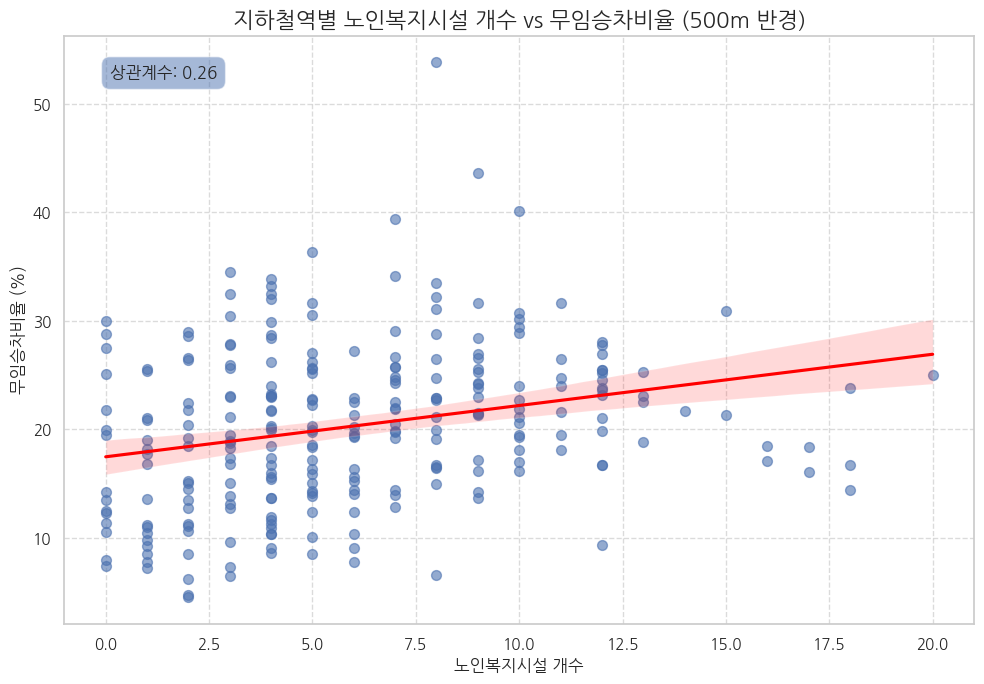

In [74]:
plt.figure(figsize=(10, 7))
sns.regplot(
    x='노인복지시설_개수',
    y='무임승차비율',
    data=final_result_500m,
    scatter_kws={'alpha':0.6, 's':50},
    line_kws={'color':'red'}
)
plt.title('지하철역별 노인복지시설 개수 vs 무임승차비율 (500m 반경)', fontsize=16)
plt.xlabel('노인복지시설 개수', fontsize=12)
plt.ylabel('무임승차비율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

correlation = final_result_500m['노인복지시설_개수'].corr(final_result_500m['무임승차비율'])
plt.text(
    0.05, 0.95,
    f'상관계수: {correlation:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', alpha=0.5)
)

plt.tight_layout()
plt.show()

## 가설 A-2. 추가 EDA

### 부록 6-1. 월별 비교

In [75]:
# 노인 승차 데이터 생성
노인_승차_요일 = 노인_df[노인_df['승하차구분'] == '승차'].copy()

# 날짜 타입 변환
노인_승차_요일['수송일자'] = pd.to_datetime(노인_승차_요일['수송일자'])

# 일별 총 승차인원 계산
노인_승차_요일['일별합계'] = 노인_승차_요일[시간대_컬럼].sum(axis=1)

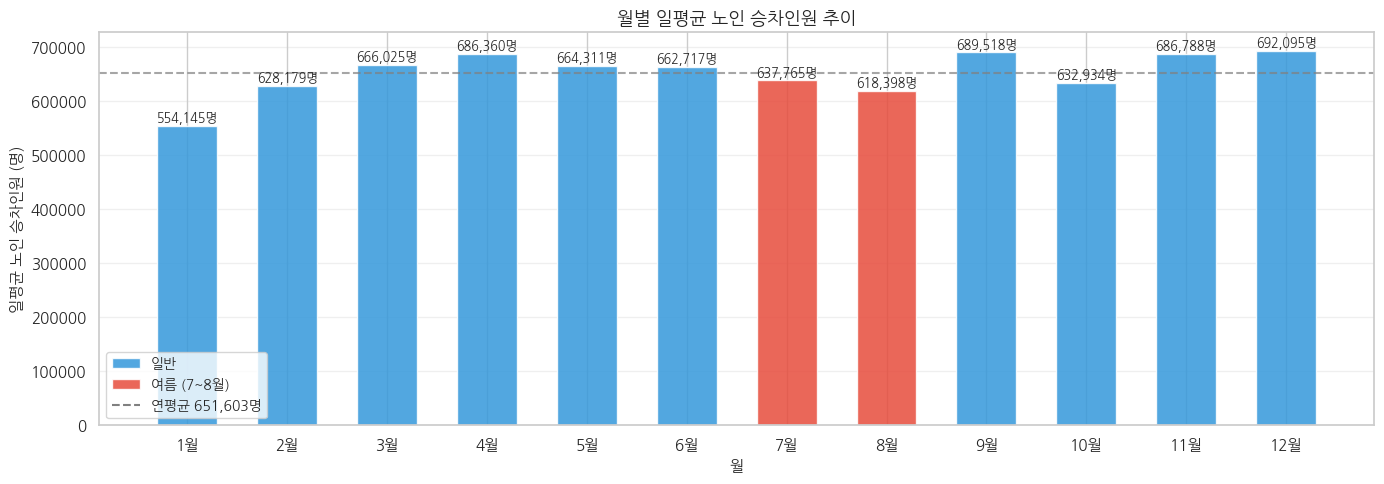

In [76]:
# 월별 추이
노인_승차_요일['월'] = 노인_승차_요일['수송일자'].dt.month

월별_합계 = (
    노인_승차_요일.groupby(['수송일자', '월'])['일별합계']
    .sum()
    .reset_index()
    .groupby('월')['일별합계']
    .mean()
    .reset_index()
    .rename(columns={'일별합계': '일평균_노인승차'})
)

월_한글 = [f'{m}월' for m in 월별_합계['월']]

fig, ax = plt.subplots(figsize=(14, 5))

colors_월 = ['#E74C3C' if m in [7, 8] else '#3498DB' for m in 월별_합계['월']]

bars = ax.bar(월_한글, 월별_합계['일평균_노인승차'],
              color=colors_월, alpha=0.85, width=0.6)

for bar, val in zip(bars, 월별_합계['일평균_노인승차']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 월별_합계['일평균_노인승차'].max() * 0.01,
        f'{val:,.0f}명',
        ha='center', fontsize=9
    )

# 평균선
평균 = 월별_합계['일평균_노인승차'].mean()
ax.axhline(평균, color='gray', linestyle='--', alpha=0.7, label=f'연평균 {평균:,.0f}명')

ax.set_title('월별 일평균 노인 승차인원 추이', fontsize=13)
ax.set_ylabel('일평균 노인 승차인원 (명)', fontsize=11)
ax.set_xlabel('월', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498DB', alpha=0.85, label='일반'),
    Patch(facecolor='#E74C3C', alpha=0.85, label='여름 (7~8월)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label=f'연평균 {평균:,.0f}명')
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()